In [841]:
import ast
import os
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.decomposition import PCA, FastICA
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    average_precision_score, r2_score, log_loss,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from scipy.stats import rankdata



## Utility helpers

In [842]:
def load_tensor(path):
    assert os.path.exists(path), path
    return torch.load(path, map_location="cpu")

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def calculate_auc(true_val, pred_val):
    """Compute AUC, flip direction if < 0.5."""
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        auc = 1 - auc
    return auc


## Config and path helpers

In [843]:
def read_config_from_log(experiment_path):
    log_path = os.path.join(experiment_path, "log.txt")
    assert os.path.exists(log_path), log_path
    with open(log_path, "r") as f:
        first_line = f.readline().strip()
    return ast.literal_eval(first_line)


def get_data_dir_name_from_log(experiment_path):
    log_path = os.path.join(experiment_path, "log.txt")
    assert os.path.exists(log_path), log_path
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("data_dir:"):
                return os.path.basename(os.path.normpath(line.split("data_dir:", 1)[1].strip()))
            elif line.startswith("Loading existing synthetic dataset from"):
                
                return os.path.basename(os.path.normpath(line.split("Loading existing synthetic dataset from", 1)[1].strip()))
    raise ValueError(f"Could not find data_dir in {log_path}")


def infer_data_path(experiment_path):
    """Resolve absolute path to the saved dataset directory."""
    data_dir_name = get_data_dir_name_from_log(experiment_path)
    candidate = os.path.join("datasets", "multilabel_synthetic", data_dir_name)
    if os.path.exists(candidate):
        return candidate
    raise FileNotFoundError(f"Dataset not found at {candidate}")


def get_multilabel_config(experiment_path):
    """Return (num_concepts, num_residuals, num_hid_tasks, num_obs_tasks, hid_dim, obs_dim)."""
    cfg = read_config_from_log(experiment_path)
    d = cfg["data"]
    return (
        d["num_concepts"],
        d["num_residuals"],
        d.get("num_hid_tasks", 3),
        d.get("num_obs_tasks", 1),
        d["hid_dim"],
        d["obs_dim"],
    )


def print_data_info(experiment_path):
    data_path = infer_data_path(experiment_path)
    info = os.path.join(data_path, "info.txt")
    if os.path.exists(info):
        with open(info, "r") as f:
            print(f.read())


## Data loading

In [844]:
def load_split(experiment_path, data_path, split: str,
               num_concepts: int, num_residuals: int):
    """
    Load one split worth of model outputs + dataset tensors.

    Model outputs (from experiment_path/<split>/):
        c_res_mu.pt                        — Gaussian mean of [concept, residual] logits
        concepts_residuals_pred_probs_mean — mean sigmoid probs over MC samples
        concepts_residuals_pred_probs_std  — std of sigmoid probs over MC samples
        concepts_residuals_sample_mean     — mean of hard Bernoulli samples

    Dataset tensors (from data_path/<split>/):
        x, concepts, residuals, y (multilabel),
        eta_concepts, eta_residuals,
        concept_signal, residual_signal,
        s_hid, s_obs,
        w_hid, w_obs, Sigma,
        hid_task_idx, obs_task_idx
    """
    model_split = os.path.join(experiment_path, split)
    data_split = os.path.join(data_path, split)

    if not os.path.exists(model_split):
        raise FileNotFoundError(
            f"Missing {model_split}. Run training with save_concept_and_residual_channel=True."
        )
    assert os.path.exists(data_split), data_split

    c_res_mu = load_tensor(os.path.join(model_split, "c_res_mu.pt"))
    cr_probs = load_tensor(os.path.join(model_split, "concepts_residuals_pred_probs_mean.pt"))
    cr_probs_std = load_tensor(os.path.join(model_split, "concepts_residuals_pred_probs_std.pt"))
    cr_sample = load_tensor(os.path.join(model_split, "concepts_residuals_sample_mean.pt"))
    


    out = {
        # ── model outputs ──────────────────────────────────────────────
        "c_mu": c_res_mu[:, :num_concepts],
        "res_mu": c_res_mu[:, num_concepts:],
        "concept_probs": cr_probs[:, :num_concepts],
        "residual_probs": cr_probs[:, num_concepts:],
        "concept_probs_std": cr_probs_std[:, :num_concepts],
        "residual_probs_std": cr_probs_std[:, num_concepts:],
        "concept_sample_mean": cr_sample[:, :num_concepts],
        "residual_sample_mean": cr_sample[:, num_concepts:],
        # ── dataset tensors ────────────────────────────────────────────
        "x": load_tensor(os.path.join(data_split, "x.pt")),
        "concepts": load_tensor(os.path.join(data_split, "concepts.pt")),
        "hidden_residuals": load_tensor(os.path.join(data_split, "residuals.pt")),
        "y": load_tensor(os.path.join(data_split, "y.pt")),  # (n, K+J)
        "eta_concepts": load_tensor(os.path.join(data_split, "eta_concepts.pt")),
        "eta_residuals": load_tensor(os.path.join(data_split, "eta_residuals.pt")),
        "concept_signal": load_tensor(os.path.join(data_split, "concept_signal.pt")),
        "hidden_residual_signal": load_tensor(os.path.join(data_split, "residual_signal.pt")),
        "s_hid": load_tensor(os.path.join(data_split, "s_hid.pt")),  # (n, K)
        "s_obs": load_tensor(os.path.join(data_split, "s_obs.pt")),  # (n, J)
        "w_hid": load_tensor(os.path.join(data_split, "w_hid.pt")),
        "w_obs": load_tensor(os.path.join(data_split, "w_obs.pt")),
        "hid_task_idx": load_tensor(os.path.join(data_split, "hid_task_idx.pt")),
        "obs_task_idx": load_tensor(os.path.join(data_split, "obs_task_idx.pt")),
        "avg_model_covariance_matrix": load_tensor(os.path.join(model_split, "avg_covariance_matrix.pt")) if os.path.exists(os.path.join(model_split, "avg_covariance_matrix.pt")) else None,
        "data_sigma_matrix": load_tensor(os.path.join(data_split, "Sigma.pt")) if os.path.exists(os.path.join(data_split, "Sigma.pt")) else None,
    }
    

    # Sanity: row counts must agree
    n_model = out["res_mu"].shape[0]
    n_data = out["hidden_residuals"].shape[0]
    assert n_model == n_data, (
        f"{split}: model has {n_model} rows but data has {n_data}. "
        "Residual dump likely used a shuffled/drop_last loader."
    )
    return out


## Specify experiment

In [845]:

# updated alpha=1, beta=1, sigma_x = 0.01, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-02_13-13-54_337de"
# )





# updated (save avg model covariance) alpha=1, beta=1, sigma_x = 0.5, standardize=True
# EXPERIMENT_PATH = os.path.join("experiments", "scbm_residual", "multilabel_synthetic",
#                                "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-07-02_13-13-54_c7cfa"
# )

# # alpha=1, beta=0, sigma_x = 0.01, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-06-30_18-02-46_2214e"
# )


# alpha=1, beta=0, sigma_x = 0.5, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-06-30_18-02-32_80deb"
# )



# important
# alpha=1, beta=0.5, sigma_x = 0.01, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-06-30_18-02-43_18266"
# )



# alpha=1, beta=1, sigma_x = 0.5, standardize=True, block_diagonal_cov = True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_block_diagonal_cov_True_2026-07-01_17-38-56_0b96b"   
# )

# alpha=1, beta=1, sigma_x = 0.01, standardize=True, block_diagonal_cov = True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_block_diagonal_cov_True_2026-07-01_17-38-56_d2b0a"
# )


# alpha=1, beta=1, sigma_x = 0.5, standardize=True, cr_rho=0.5
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-07-05_17-40-22_25c96"
# )


# alpha=1, beta=1, sigma_x = 0.5, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_paired_cov_num_res_20_2026-07-05_19-54-17_ab403"
# )

# alpha=1, beta=1, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.75_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_2026-07-05_19-54-17_3f73e"
# )



# alpha=1, beta=1, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired, block_diagonal
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.75_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_block_diagonal_cov_True_2026-07-23_17-14-22_d6a44"
# )


# alpha=1, beta=0.2, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired, block_diagonal
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.2_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_block_diagonal_cov_True_2026-07-23_19-45-37_b2005"
# )

# alpha=1, beta=0.5, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired, block_diagonal
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_block_diagonal_cov_True_2026-07-23_19-45-37_d98b6"
# )

# alpha=1, beta=0.2, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired
EXPERIMENT_PATH = os.path.join(
    "experiments", "scbm_residual", "multilabel_synthetic",
    "K_5_J_2_alpha_1.0_beta_0.2_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_2026-07-23_23-41-08_c0ce9"
)

# alpha=1, beta=0.5, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_2026-07-23_23-41-28_02f4c"
# )




In [846]:
assert os.path.exists(EXPERIMENT_PATH), EXPERIMENT_PATH

# Resolve dataset path and config
DATA_PATH = infer_data_path(EXPERIMENT_PATH)
(num_concepts, num_residuals,
 num_hid_tasks, num_obs_tasks,
 hid_dim, obs_dim) = get_multilabel_config(EXPERIMENT_PATH)
num_tasks = num_hid_tasks + num_obs_tasks

print(f"num_concepts : {num_concepts}")
print(f"num_residuals: {num_residuals}")
print(f"num_hid_tasks: {num_hid_tasks}  (K)")
print(f"num_obs_tasks: {num_obs_tasks}  (J)")
print(f"num_tasks    : {num_tasks}  (K+J)")
print(f"hid_dim      : {hid_dim}")
print(f"obs_dim      : {obs_dim}")
print()
print_data_info(EXPERIMENT_PATH)
print(f"Block diagonal covariance: {read_config_from_log(EXPERIMENT_PATH)['model'].get('block_diagonal_cov', False)}")


num_concepts : 10
num_residuals: 20
num_hid_tasks: 5  (K)
num_obs_tasks: 2  (J)
num_tasks    : 7  (K+J)
hid_dim      : 20
obs_dim      : 10

[multilabel synthetic dataset]
num_hid_tasks : 5
num_obs_tasks : 2
num_tasks/num_classes : 7
alpha : 1.0
beta : 0.2
hid_task_idx : [5, 14, 7, 2, 17]
obs_task_idx : [4, 7]
rho_cr : 0.5
rho_cc : 0.0
rho_rr : 0.0
task_sparsity_hid : 0.25
task_sparsity_obs : 0.3
sigma_x : 0.01
hid_dim : 20
obs_dim : 10
seed : 0
train / val / test : 30000 / 10000 / 10000
min_weight_ratio : 0.4
data created for model at: /cluster/home/smarcou/work/experiments_scbm/scbm_residual/multilabel_synthetic/K_5_J_2_alpha_1.0_beta_0.2_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_block_diagonal_cov_True_2026-07-23_19-45-37_b2005
standardize : True
latent_rank : 10
concepts_per_hid_task : 1
cov_structure : paired

Block diagonal covariance: False


## Load data splits

In [847]:
train_data = load_split(EXPERIMENT_PATH, DATA_PATH, "train",
                        num_concepts=num_concepts, num_residuals=num_residuals)
val_data = load_split(EXPERIMENT_PATH, DATA_PATH, "val",
                        num_concepts=num_concepts, num_residuals=num_residuals)
test_data = load_split(EXPERIMENT_PATH, DATA_PATH, "test",
                        num_concepts=num_concepts, num_residuals=num_residuals)
splits = {"train": train_data, "val": val_data, "test": test_data}

for split_name, data in splits.items():
    print(f"{split_name}:")
    for key in ["x", "res_mu", "hidden_residuals", "y", "s_hid", "s_obs"]:
        print(f"  {key:28s} {tuple(data[key].shape)}")

w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]
hid_task_idx = train_data["hid_task_idx"]  # (K,) — which hidden concepts are task bits
obs_task_idx = train_data["obs_task_idx"]  # (J,)


train:
  x                            (30000, 100)
  res_mu                       (30000, 20)
  hidden_residuals             (30000, 20)
  y                            (30000, 7)
  s_hid                        (30000, 5)
  s_obs                        (30000, 2)
val:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)
test:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)


## Task weights and task index mapping

In [848]:
# Hidden task weights — sorted by abs magnitude
df_w_hid = pd.DataFrame({
    "hidden_concept_idx": np.arange(w_hid.shape[0]),
    "weight": to_numpy(w_hid),
    "abs_weight": to_numpy(w_hid.abs()),
    "is_task_bit": [i in hid_task_idx.tolist() for i in range(w_hid.shape[0])],
})
df_w_hid = df_w_hid[df_w_hid["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

# Annotate which subtask index each hidden concept maps to
task_map_hid = {int(idx): k for k, idx in enumerate(hid_task_idx.tolist())}
print(f"task_map_hid: {task_map_hid}")
df_w_hid["hid_task_k"] = df_w_hid["hidden_concept_idx"].map(task_map_hid)

print("Hidden concept weights (K task bits highlighted):")
display(df_w_hid)

# Observed task weights
df_w_obs = pd.DataFrame({
    "observed_concept_idx": np.arange(w_obs.shape[0]),
    "weight": to_numpy(w_obs),
    "abs_weight": to_numpy(w_obs.abs()),
    "is_task_bit": [i in obs_task_idx.tolist() for i in range(w_obs.shape[0])],
})
df_w_obs = df_w_obs[df_w_obs["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

task_map_obs = {int(idx): j for j, idx in enumerate(obs_task_idx.tolist())}
print(f"task_map_obs: {task_map_obs}")
df_w_obs["obs_task_j"] = df_w_obs["observed_concept_idx"].map(task_map_obs)

print("\nObserved concept weights (J task bits highlighted):")
display(df_w_obs)


task_map_hid: {5: 0, 14: 1, 7: 2, 2: 3, 17: 4}
Hidden concept weights (K task bits highlighted):


,hidden_concept_idx,weight,abs_weight,is_task_bit,hid_task_k
5,5,0.974940,0.974940,True,0
14,14,-0.952066,0.952066,True,1
7,7,0.891934,0.891934,True,2
2,2,-0.609588,0.609588,True,3
17,17,0.549488,0.549488,True,4


task_map_obs: {4: 0, 7: 1}

Observed concept weights (J task bits highlighted):


,observed_concept_idx,weight,abs_weight,is_task_bit,obs_task_j
4,4,0.930378,0.930378,True,0.0
7,7,0.841165,0.841165,True,1.0
1,1,0.621388,0.621388,False,NaN


## Plot dataset balance

In [849]:
for split_name, data in splits.items():
    y = data["y"]
    label_ratio = y.mean(dim=0).detach().cpu().numpy()
    col = ["label ratio"] + [f"task {k}" for k in range(num_tasks)]
    df_label_ratio = pd.DataFrame({
        "task_idx": np.arange(num_tasks),
        "label_ratio": label_ratio,
    })
    print(f"{split_name}")
    display(df_label_ratio)
    

train


,task_idx,label_ratio
0,0,0.499333
1,1,0.501700
2,2,0.499733
3,3,0.499567
4,4,0.500267
5,5,0.496300
6,6,0.495467


val


,task_idx,label_ratio
0,0,0.4962
1,1,0.4983
2,2,0.4965
3,3,0.5008
4,4,0.4960
5,5,0.4994
6,6,0.5050


test


,task_idx,label_ratio
0,0,0.5058
1,1,0.4966
2,2,0.5043
3,3,0.5005
4,4,0.5032
5,5,0.5117
6,6,0.5086


## Data covariance

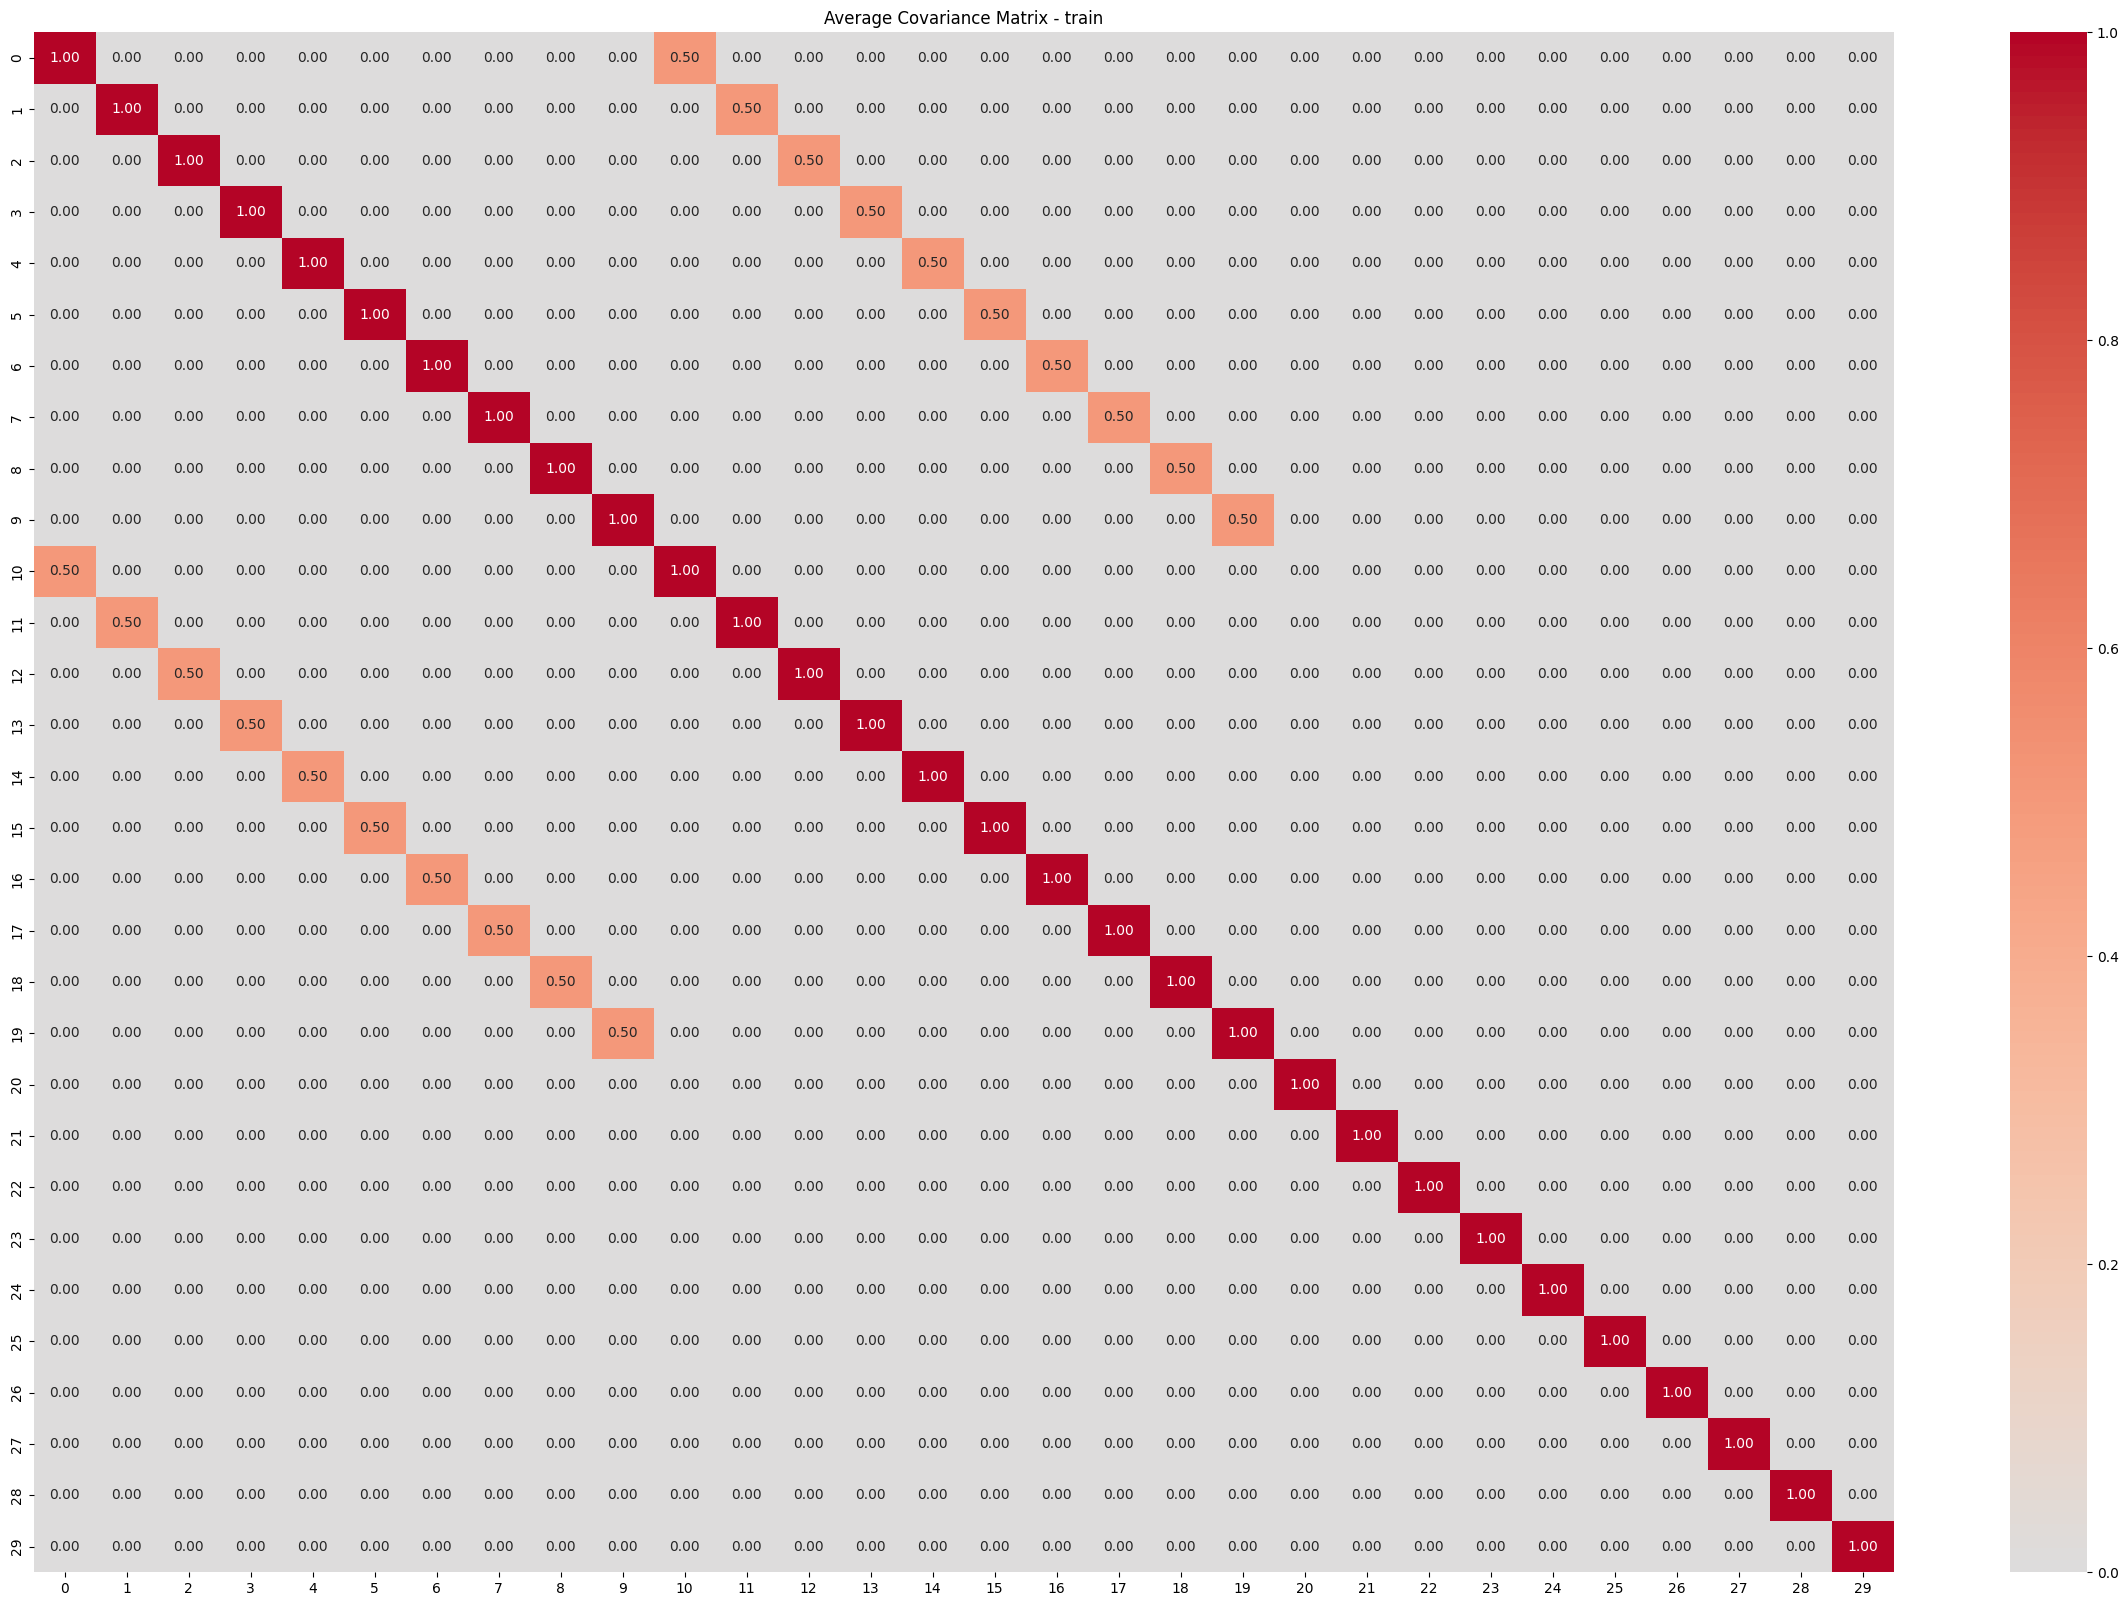

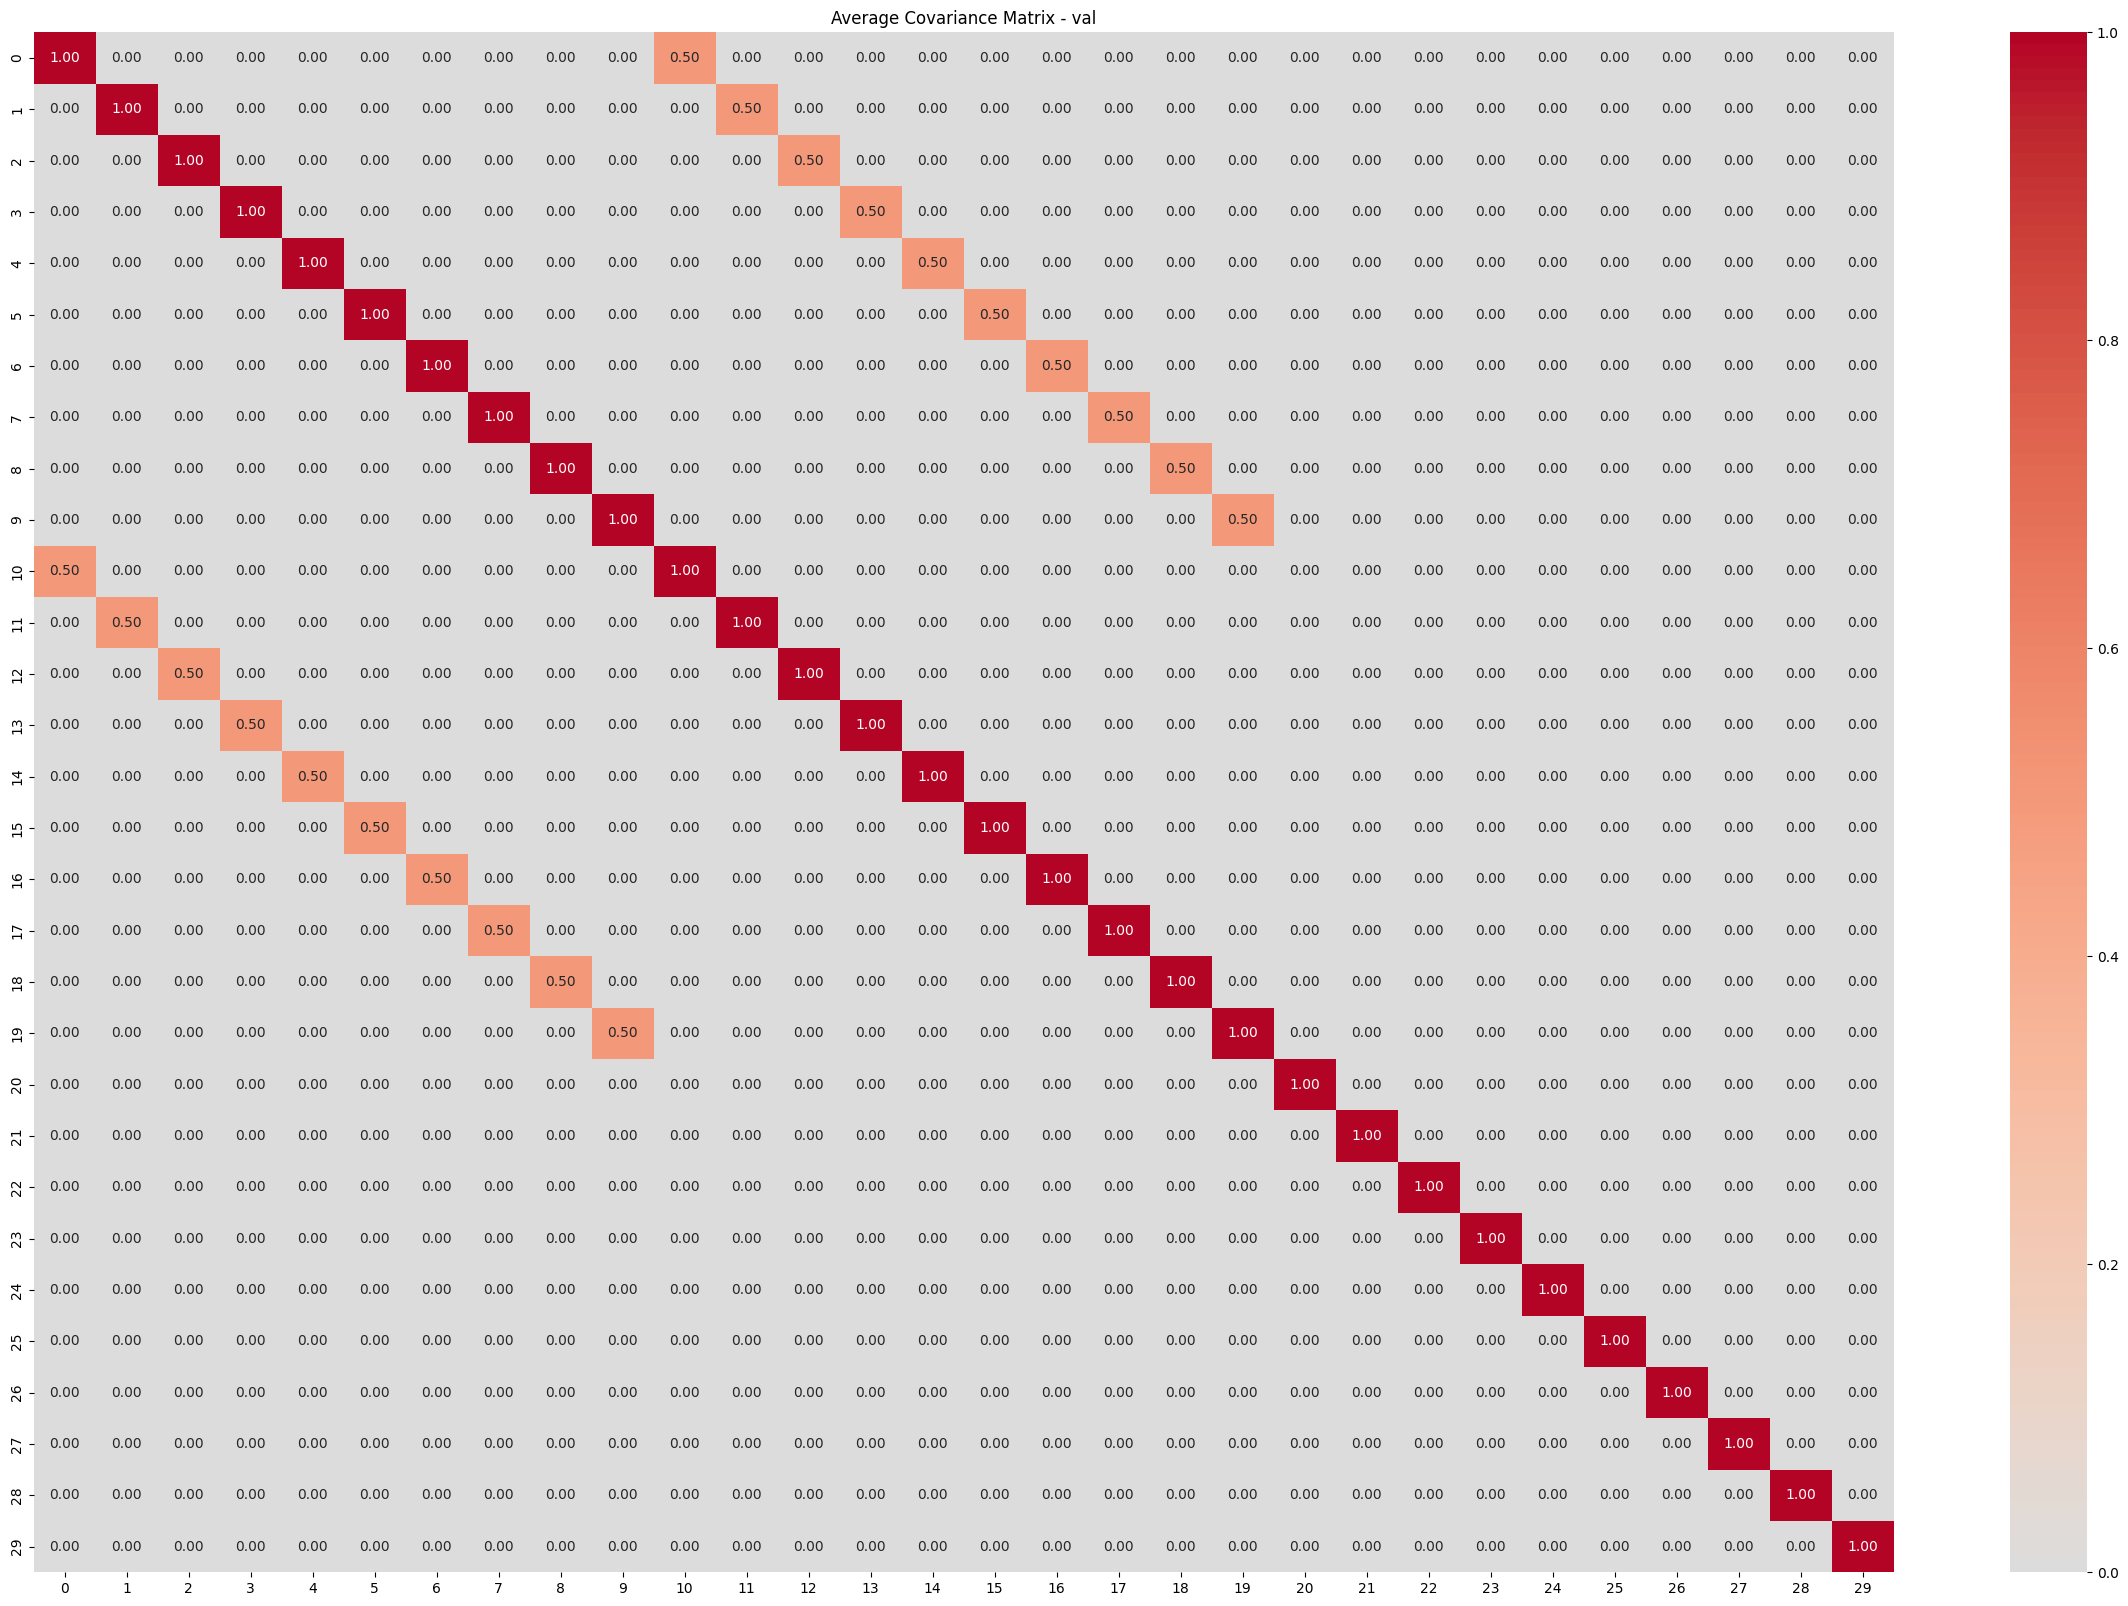

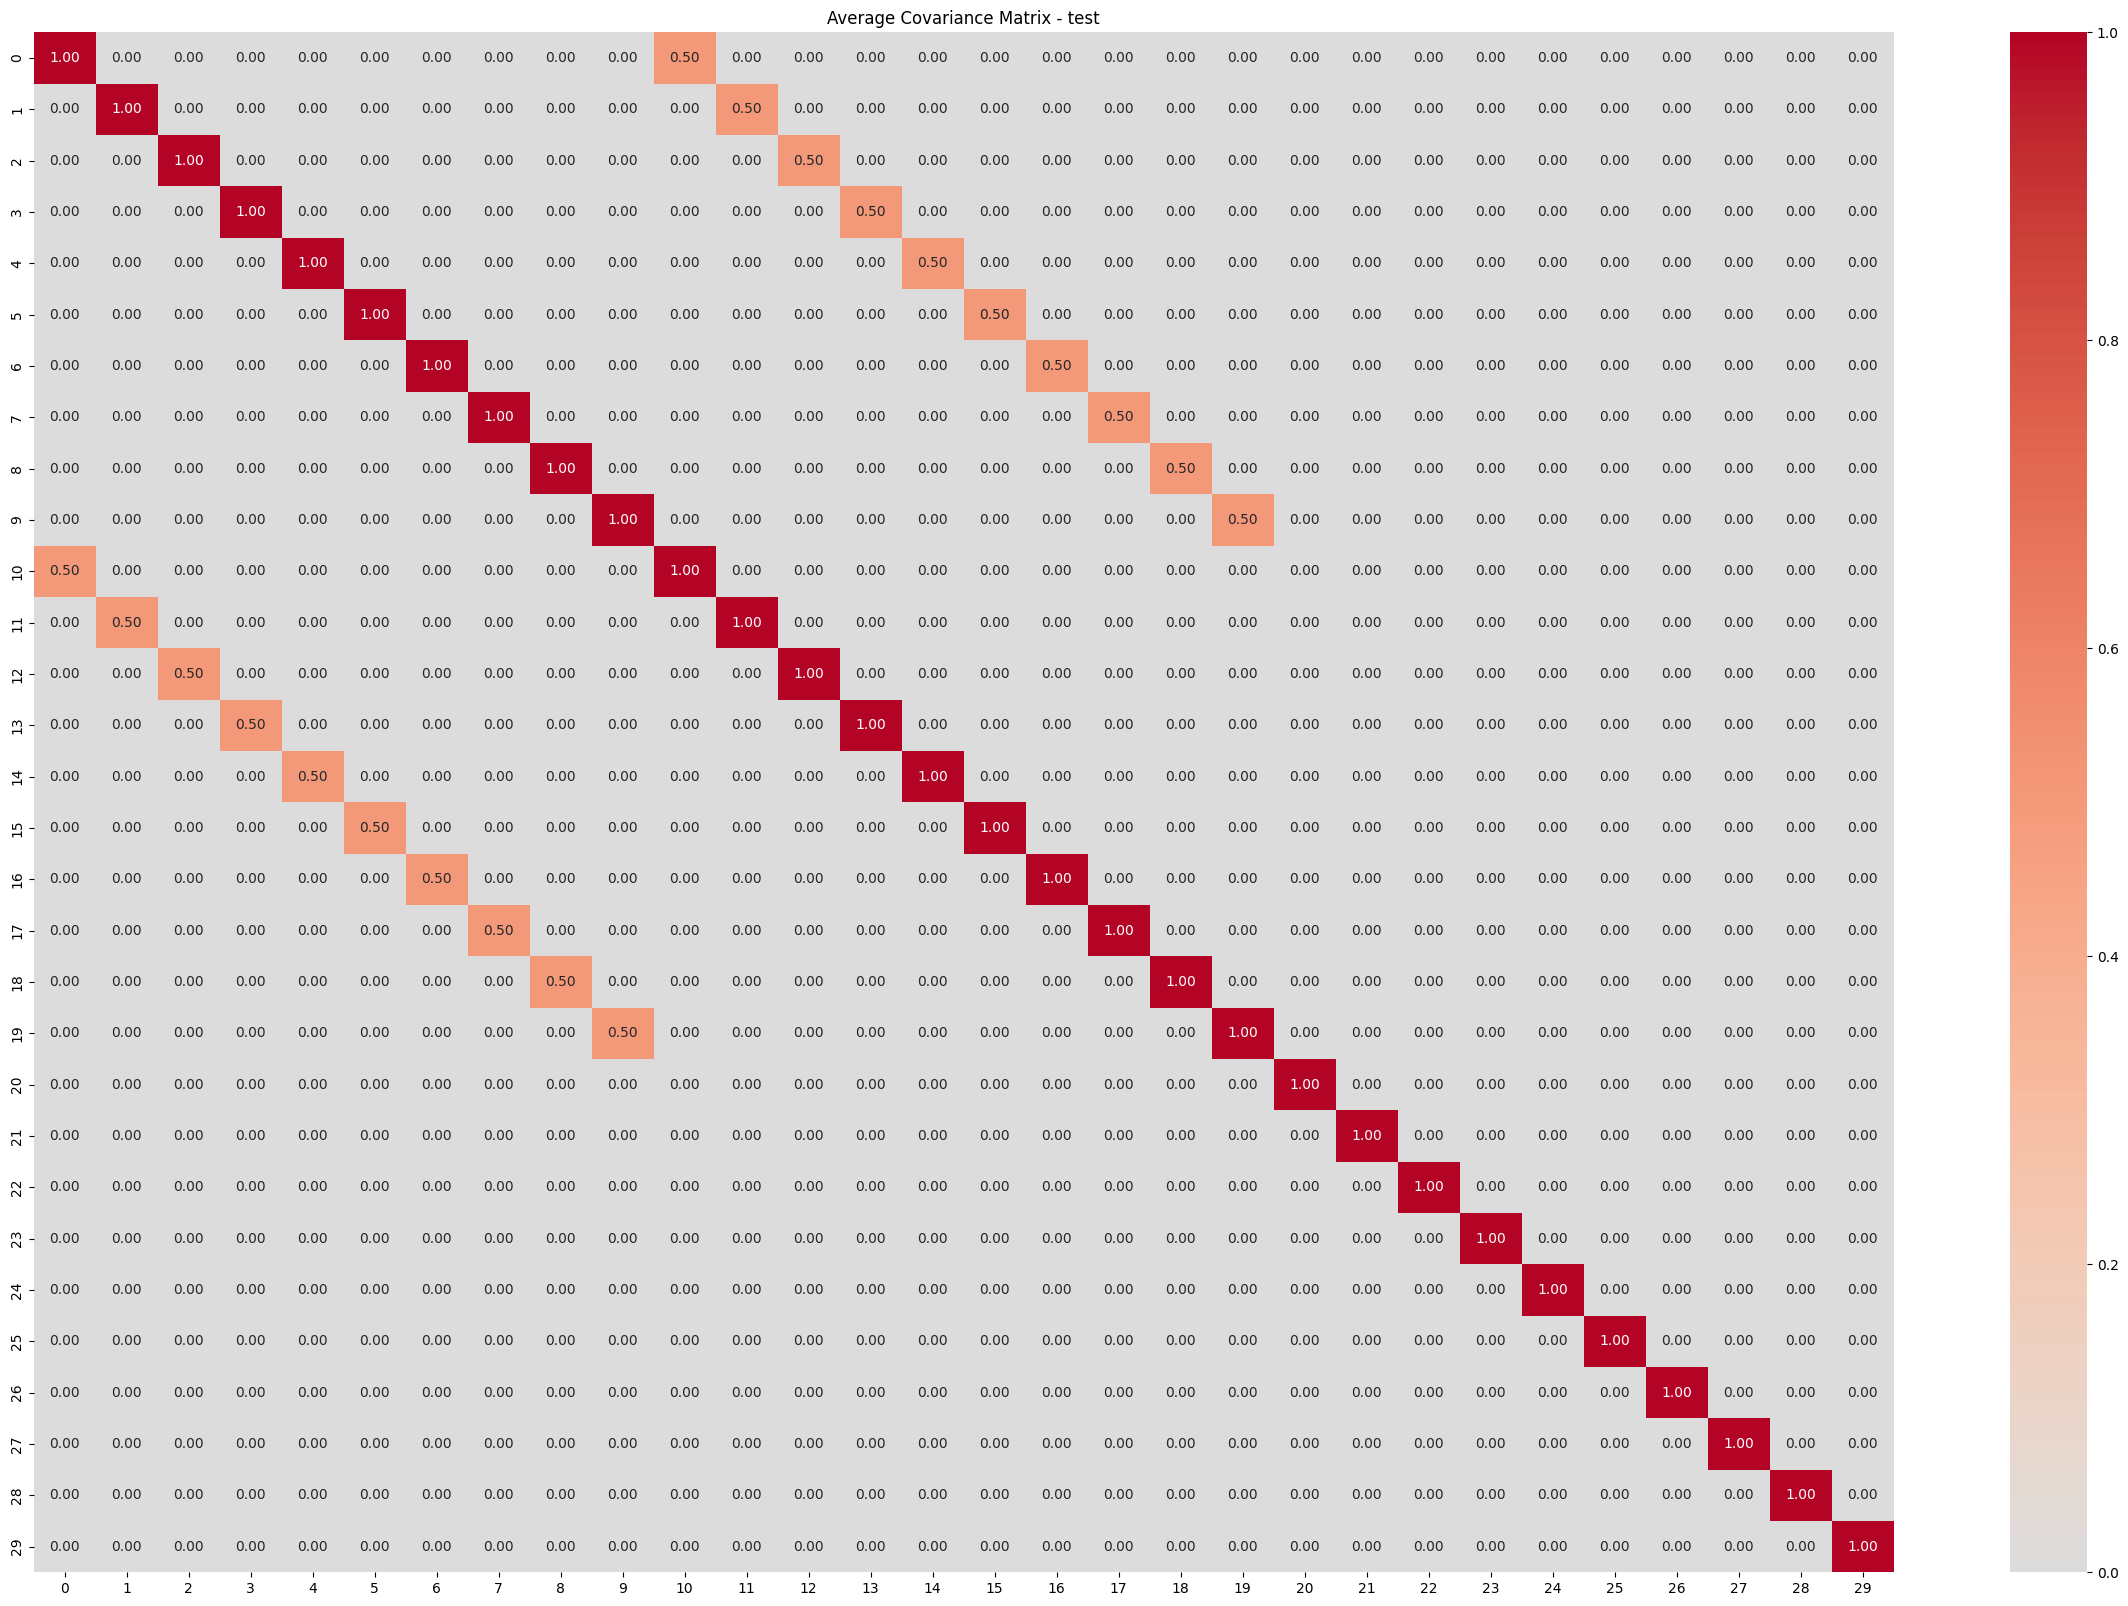

In [850]:
for split_name, data in splits.items():
    avg_cov = data["data_sigma_matrix"]
    if avg_cov is not None:
        plt.figure(figsize=(30, 20))
        sns.heatmap(avg_cov, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title(f"Average Covariance Matrix - {split_name}")
        plt.show()
        
        


## Model covariance

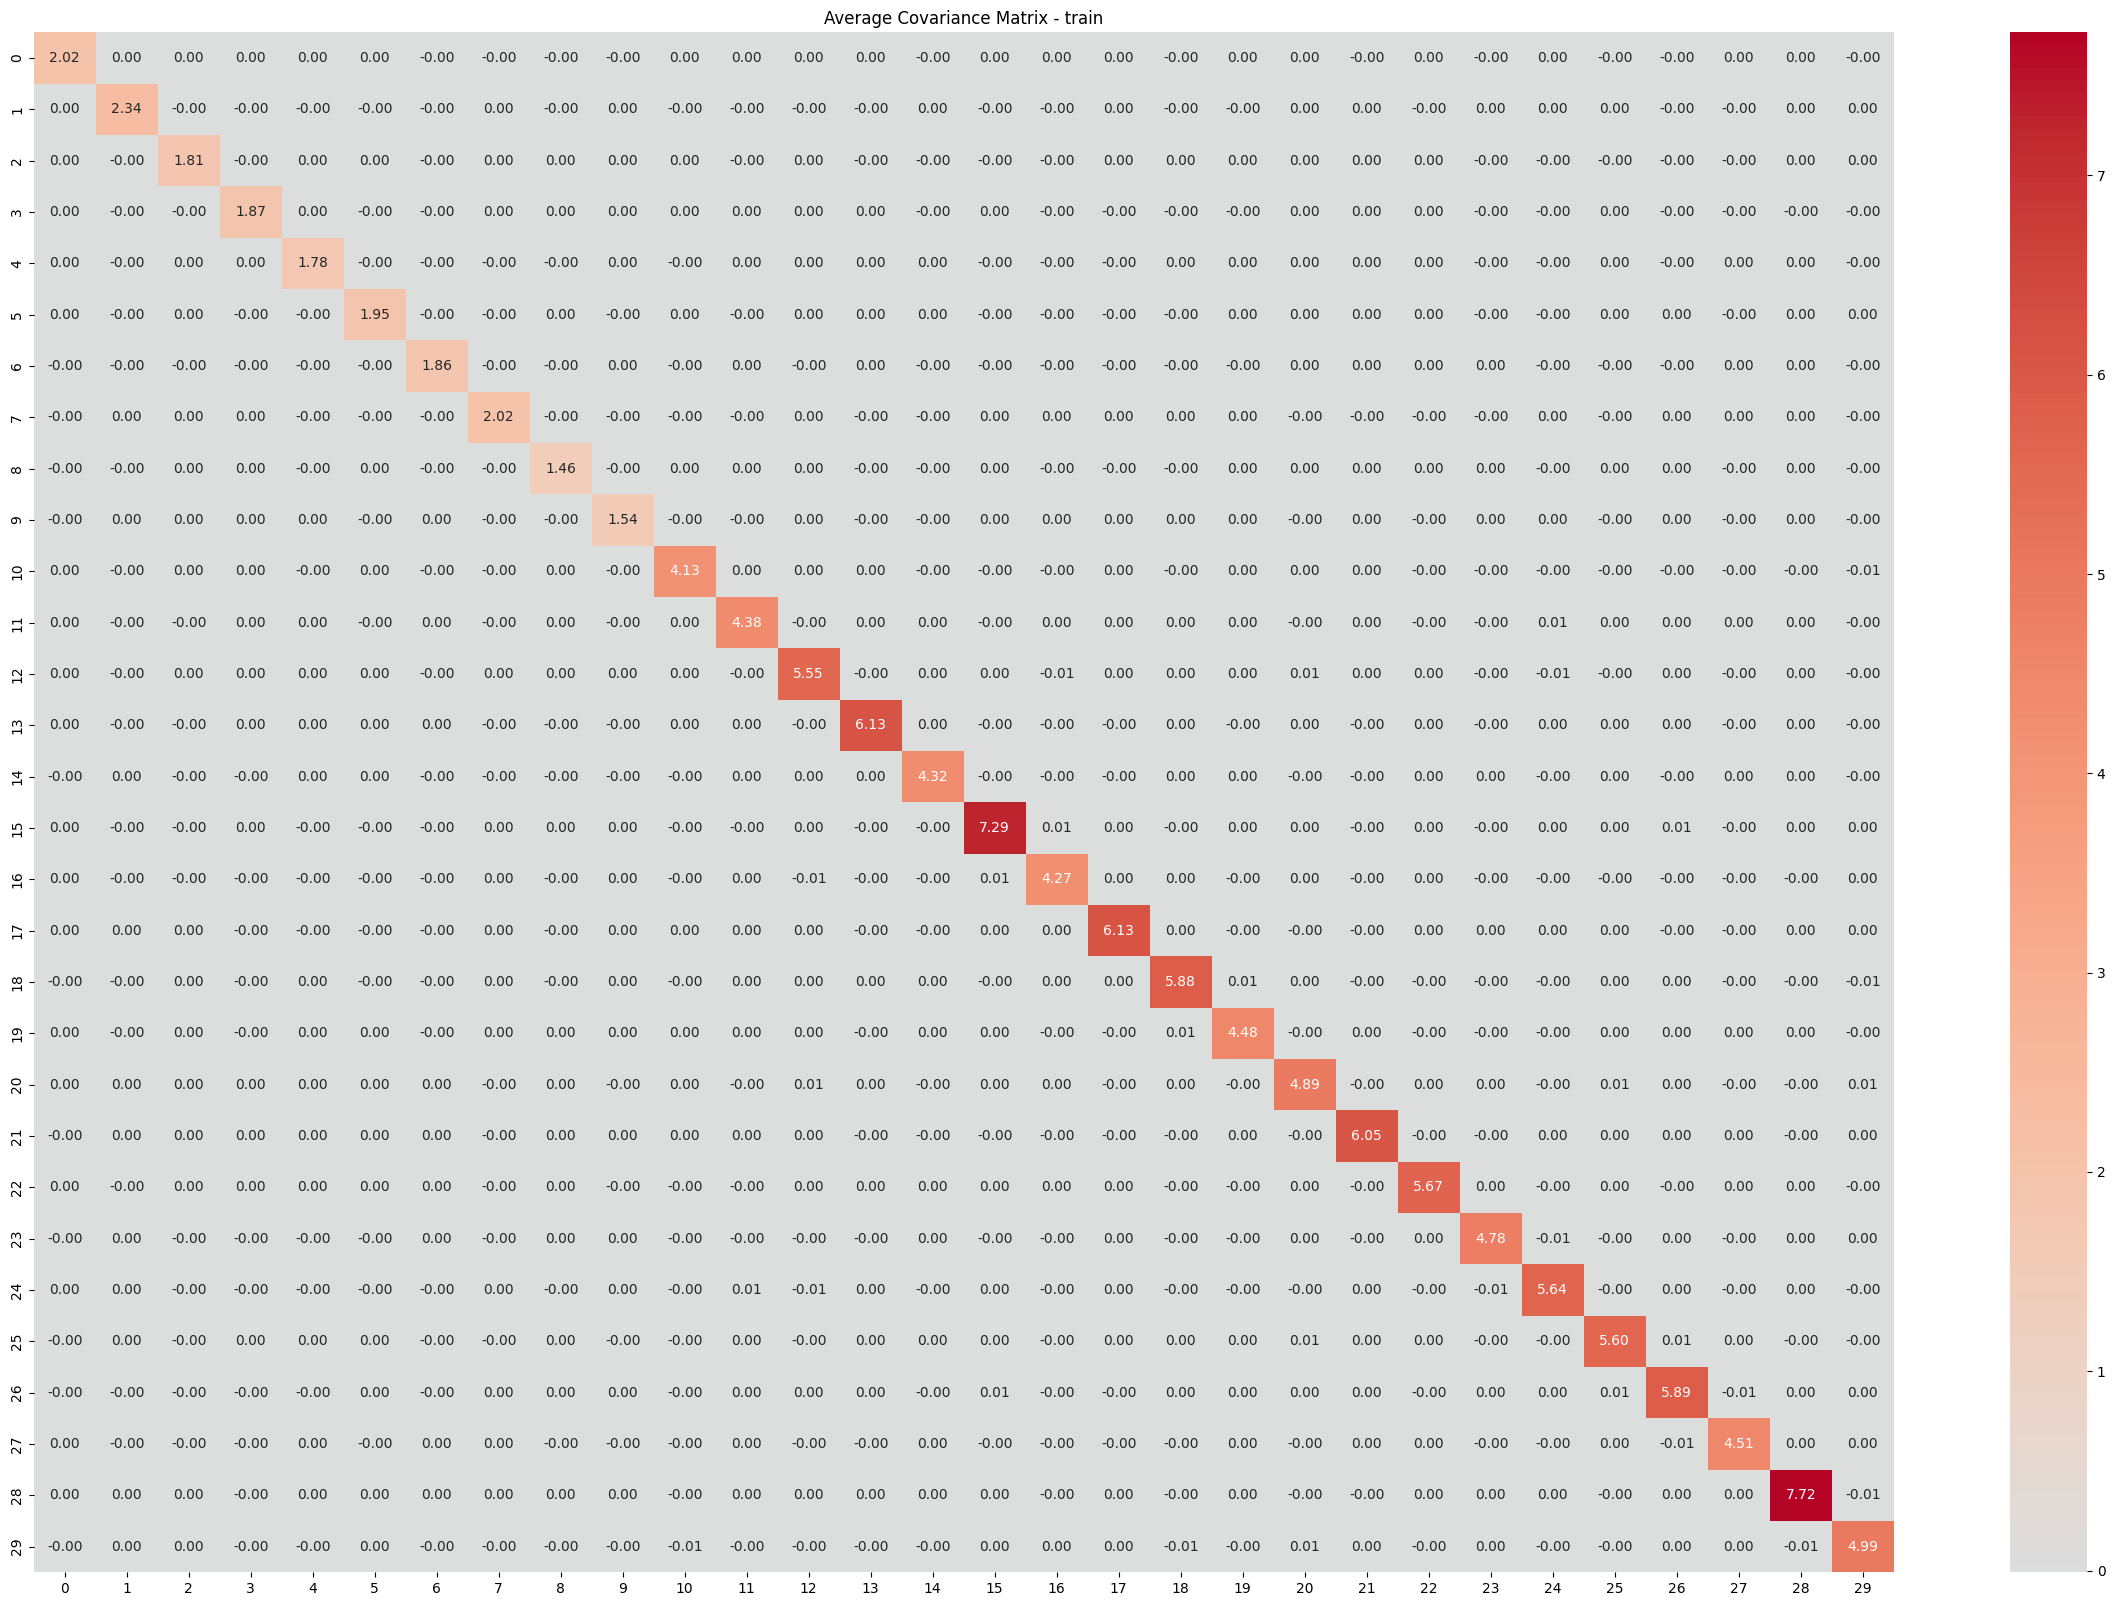

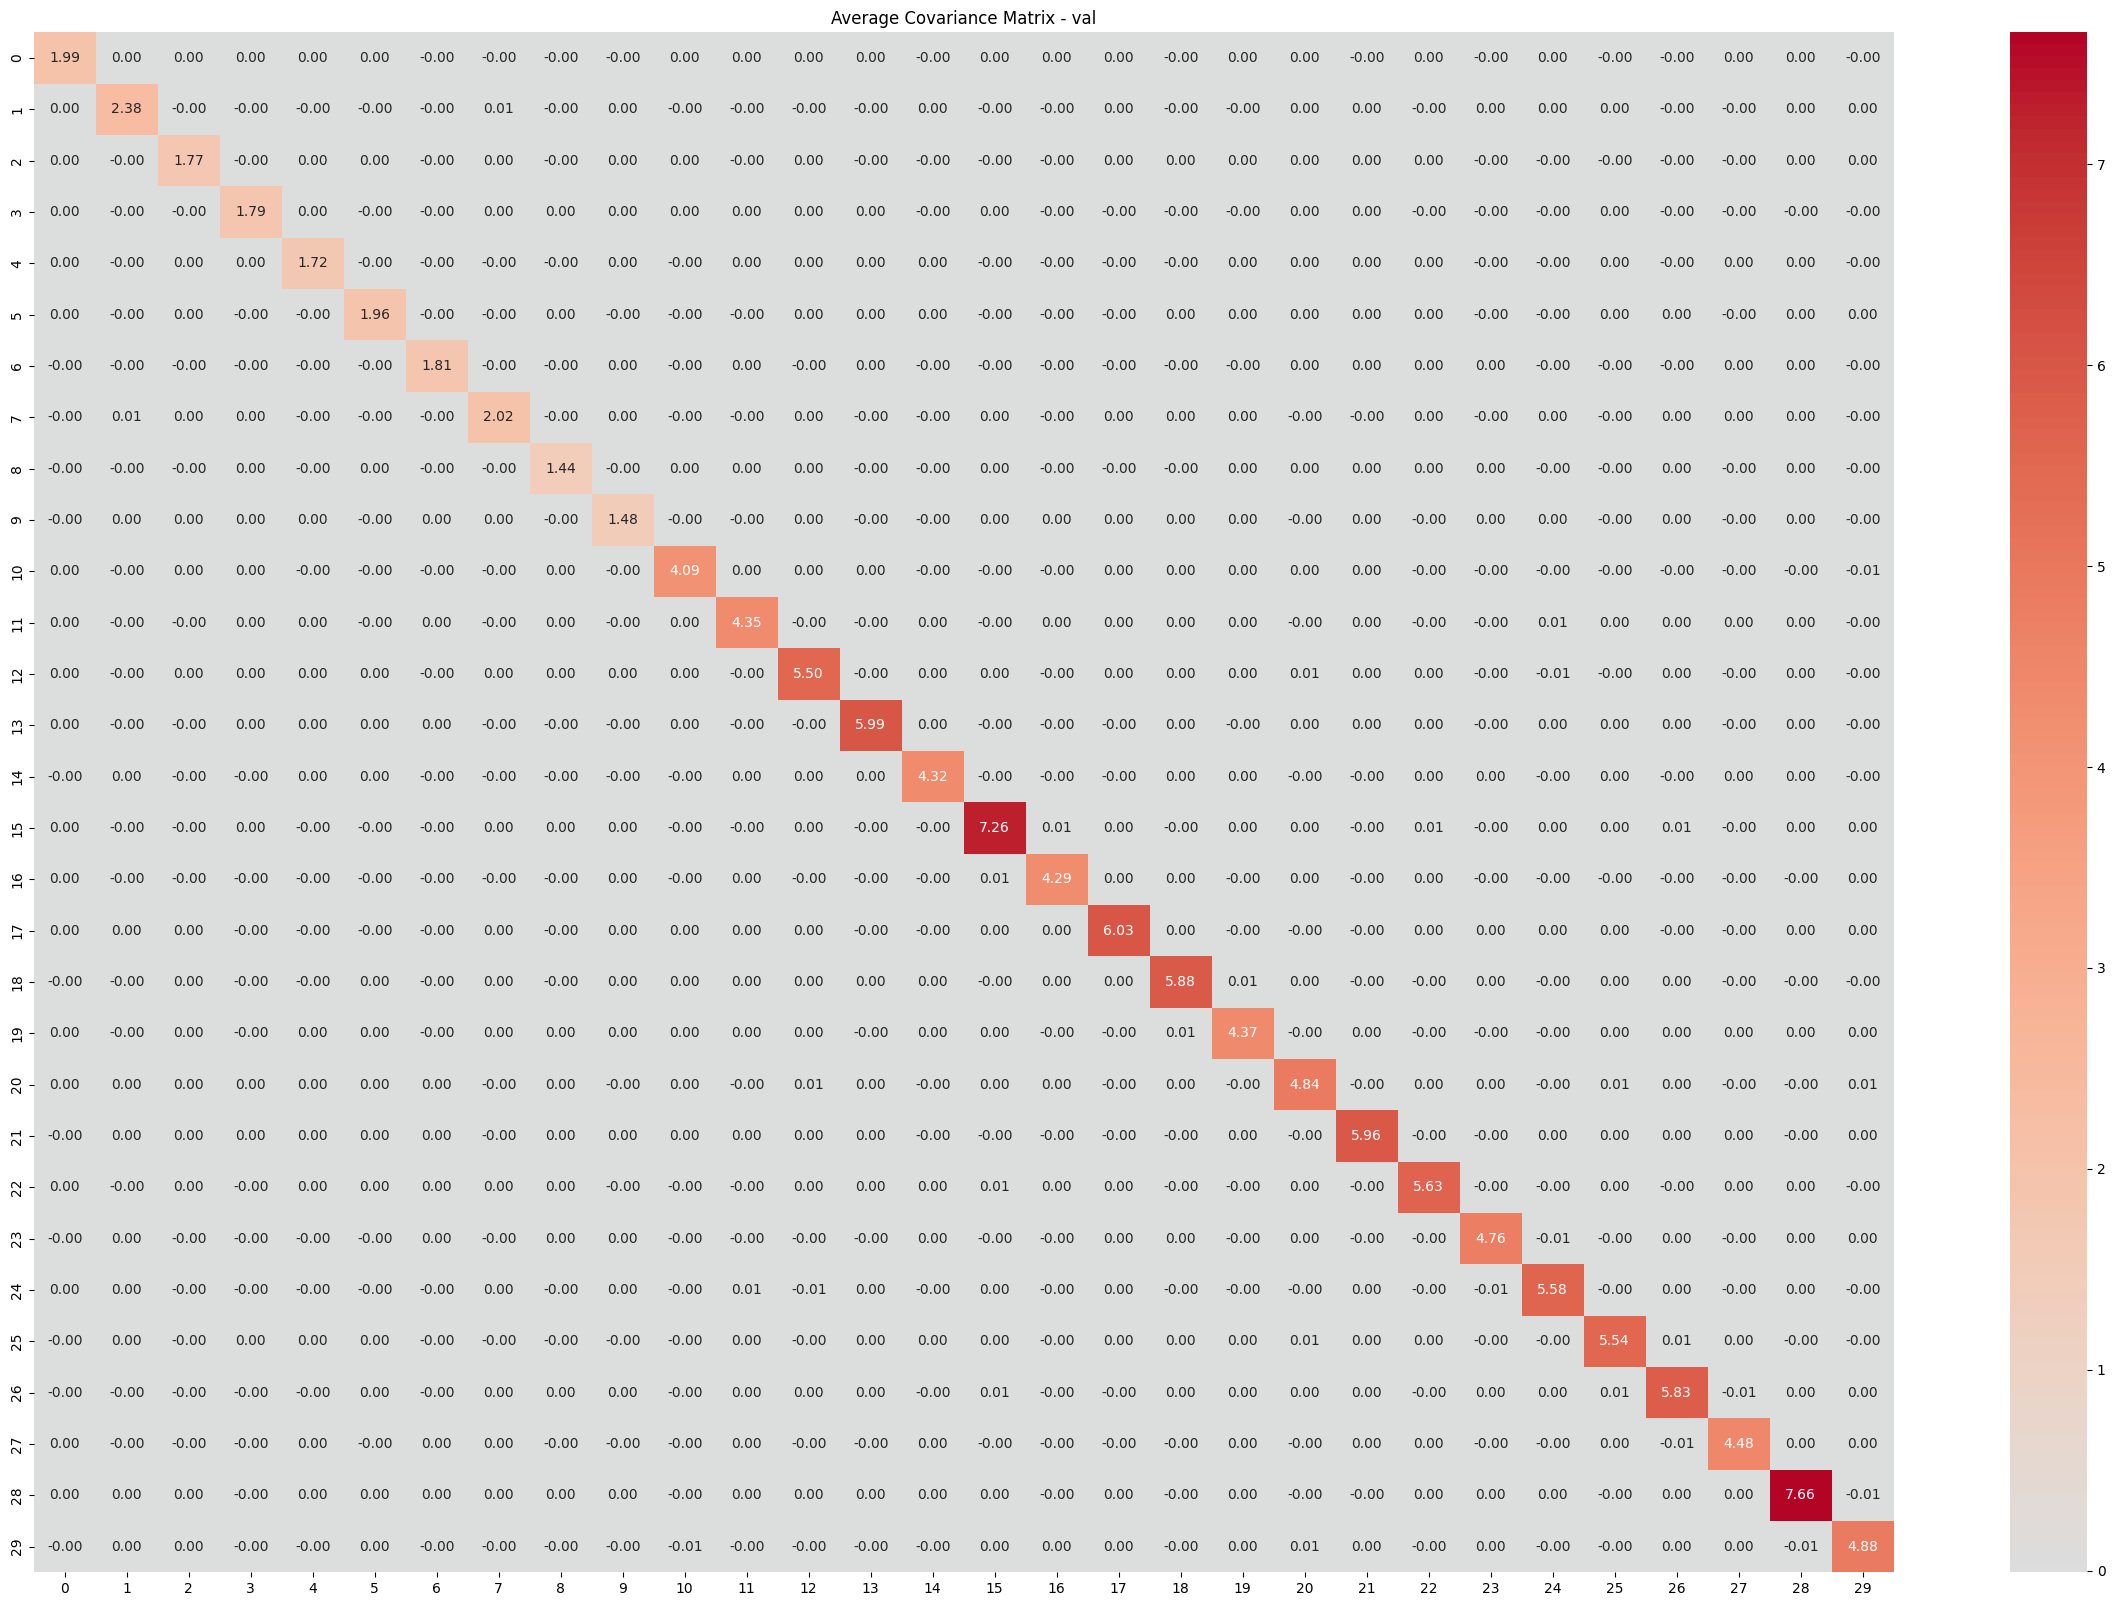

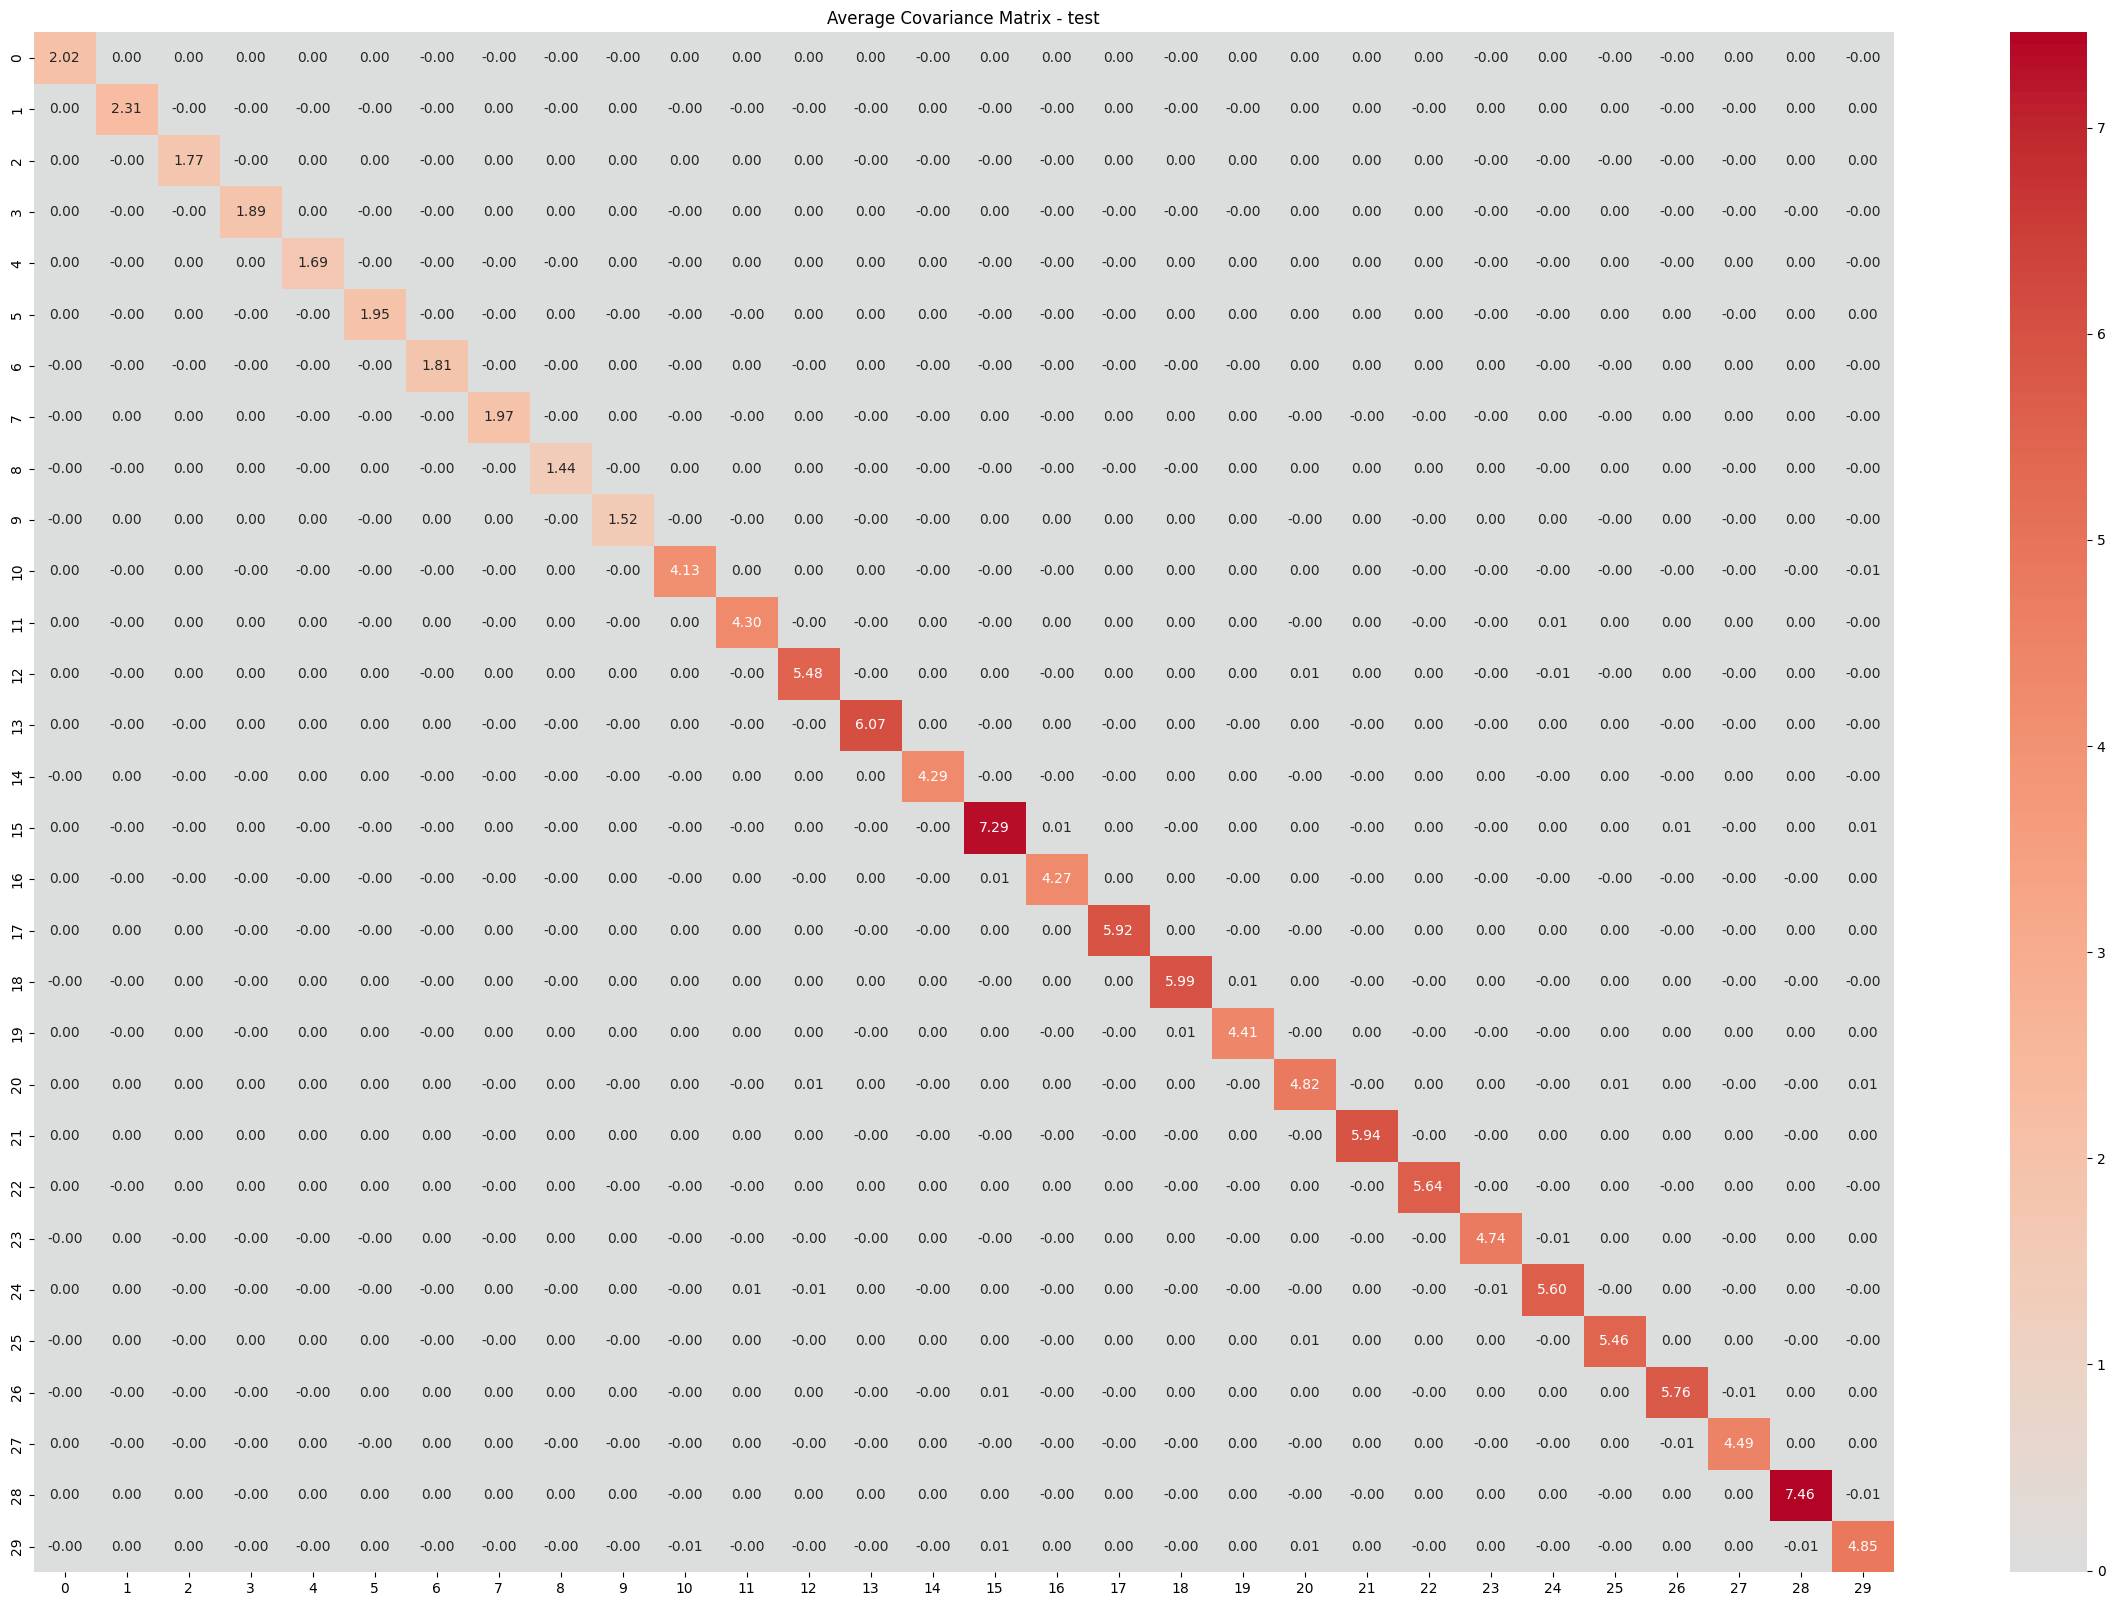

In [851]:
for split_name, data in splits.items():
    avg_cov = data["avg_model_covariance_matrix"]
    if avg_cov is not None:
        plt.figure(figsize=(30, 20))
        sns.heatmap(avg_cov, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title(f"Average Covariance Matrix - {split_name}")
        plt.show()
        
        

        

## Raw axis AUC matrix — hidden concepts vs residual dimensions

Each cell = AUC of residual dimension r_j for predicting hidden concept h_i. Task-bit rows (hid_task_idx) should show elevated AUC; other rows should be ~0.5.

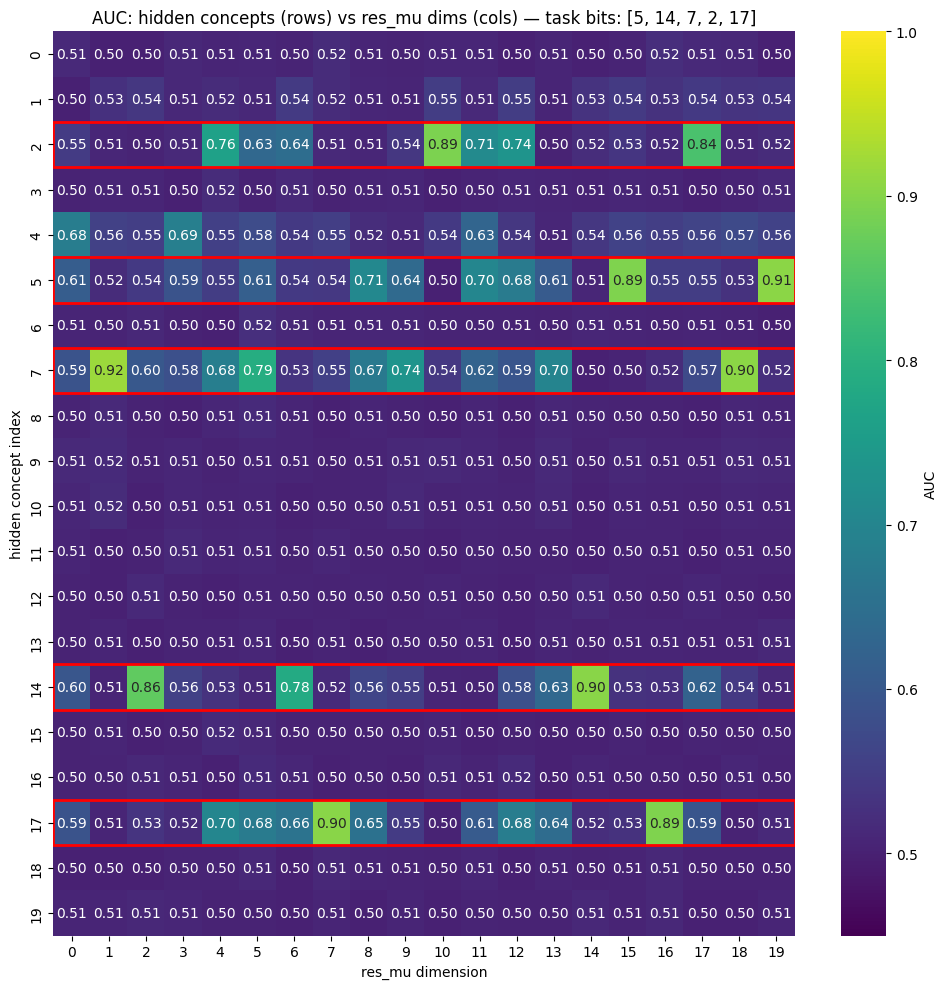

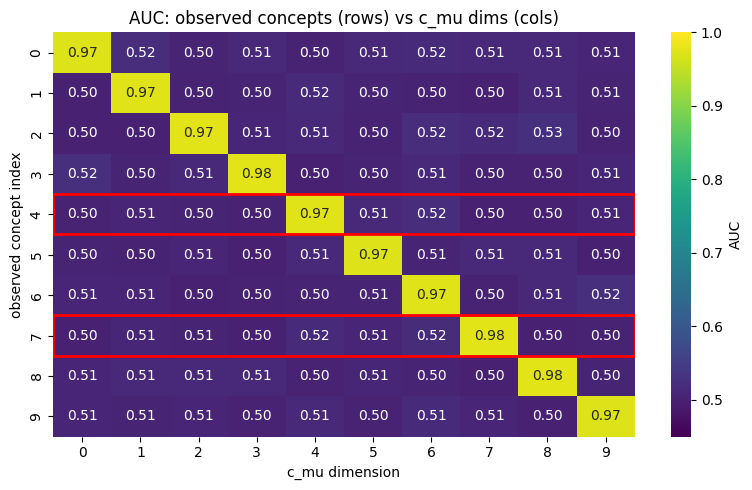

In [852]:
def auc_matrix(true_labels, pred_scores):
    """Compute AUC for every (row, col) pair. Shape: (n_true, n_pred)."""
    n_true = true_labels.shape[1]
    n_pred = pred_scores.shape[1]
    mat = np.zeros((n_true, n_pred))
    for i in range(n_true):
        for j in range(n_pred):
            if len(np.unique(true_labels[:, i])) > 1:
                mat[i, j] = calculate_auc(true_labels[:, i], pred_scores[:, j])
            else:
                mat[i, j] = np.nan
    return mat


def plot_heatmap(mat, title, x_label, y_label, annot=True,
                 highlight_rows=None, highlight_cols=None):
    fig, ax = plt.subplots(figsize=(max(8, mat.shape[1] * 0.5),
                                    max(5, mat.shape[0] * 0.5)))
    sns.heatmap(mat, annot=annot, fmt=".2f", cmap="viridis",
                vmin=0.45, vmax=1.0, ax=ax, cbar_kws={"label": "AUC"})
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if highlight_rows is not None:
        for r in highlight_rows:
            ax.add_patch(plt.Rectangle((0, r), mat.shape[1], 1,
                         fill=False, edgecolor="red", lw=2))
    plt.tight_layout()
    plt.show()


# Hidden concepts vs residual dimensions
auc_mat_hid_res = auc_matrix(
    to_numpy(test_data["hidden_residuals"]),
    to_numpy(test_data["res_mu"]),
)
plot_heatmap(
    auc_mat_hid_res,
    title=f"AUC: hidden concepts (rows) vs res_mu dims (cols) — task bits: {hid_task_idx.tolist()}",
    x_label="res_mu dimension",
    y_label="hidden concept index",
    highlight_rows=hid_task_idx.tolist(),
    annot=True,
)

# Observed concepts vs c_mu (ceiling reference)
auc_mat_obs_cmu = auc_matrix(
    to_numpy(test_data["concepts"]),
    to_numpy(test_data["c_mu"]),
)
plot_heatmap(
    auc_mat_obs_cmu,
    title="AUC: observed concepts (rows) vs c_mu dims (cols)",
    x_label="c_mu dimension",
    y_label="observed concept index",
    highlight_rows=obs_task_idx.tolist(),
    annot=True,
)


# Sparse atom model

In [853]:
# ============================================================
# Block 0: Imports
# ============================================================
# This block imports PyTorch for model training, NumPy for array handling,
# sklearn for AUROC evaluation, and matplotlib for visualizing learned atoms.

import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
from scipy.optimize import linear_sum_assignment


# ============================================================
# Block 1: Helper function for converting tensors to NumPy
# ============================================================
# This is useful because your notebook likely has tensors, NumPy arrays,
# or maybe PyTorch tensors on GPU. This function makes everything NumPy.

def to_numpy_safe(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

In [854]:
# ============================================================
# Block 2: Extract residual means, concept means, and labels
# ============================================================
# R = residual means, shape (n, 20)
# C = observed concept means, shape (n, 10)
# Y = multilabel targets, shape (n, T), where T = 7 in your case.

R_train_raw = to_numpy_safe(train_data["res_mu"]).astype(np.float32)
R_val_raw   = to_numpy_safe(val_data["res_mu"]).astype(np.float32)
R_test_raw  = to_numpy_safe(test_data["res_mu"]).astype(np.float32)

C_train_raw = to_numpy_safe(train_data["c_mu"]).astype(np.float32)
C_val_raw   = to_numpy_safe(val_data["c_mu"]).astype(np.float32)
C_test_raw  = to_numpy_safe(test_data["c_mu"]).astype(np.float32)

Y_train = to_numpy_safe(train_data["y"]).astype(np.float32)
Y_val   = to_numpy_safe(val_data["y"]).astype(np.float32)
Y_test  = to_numpy_safe(test_data["y"]).astype(np.float32)

print("R_train:", R_train_raw.shape)
print("C_train:", C_train_raw.shape)
print("Y_train:", Y_train.shape)

R_train: (30000, 20)
C_train: (30000, 10)
Y_train: (30000, 7)


In [855]:
# ============================================================
# Block 3: Standardize r and c using train statistics
# ============================================================
# The atom model uses linear projections, so standardization matters.
# We fit means/stds only on train data and apply them to val/test.

eps = 1e-8

R_mean = R_train_raw.mean(axis=0, keepdims=True)
R_std  = R_train_raw.std(axis=0, keepdims=True) + eps

C_mean = C_train_raw.mean(axis=0, keepdims=True)
C_std  = C_train_raw.std(axis=0, keepdims=True) + eps

R_train = (R_train_raw - R_mean) / R_std
R_val   = (R_val_raw   - R_mean) / R_std
R_test  = (R_test_raw  - R_mean) / R_std

C_train = (C_train_raw - C_mean) / C_std
C_val   = (C_val_raw   - C_mean) / C_std
C_test  = (C_test_raw  - C_mean) / C_std

In [856]:
# ============================================================
# Block 4: Create PyTorch dataloaders
# ============================================================
# Each batch contains:
#   r: standardized residual means
#   c: standardized observed concept means
#   y: multilabel task targets

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

batch_size = 512

train_ds = TensorDataset(
    torch.tensor(R_train, dtype=torch.float32),
    torch.tensor(C_train, dtype=torch.float32),
    torch.tensor(Y_train, dtype=torch.float32),
)

val_ds = TensorDataset(
    torch.tensor(R_val, dtype=torch.float32),
    torch.tensor(C_val, dtype=torch.float32),
    torch.tensor(Y_val, dtype=torch.float32),
)

test_ds = TensorDataset(
    torch.tensor(R_test, dtype=torch.float32),
    torch.tensor(C_test, dtype=torch.float32),
    torch.tensor(Y_test, dtype=torch.float32),
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Using device: cpu


In [857]:
# ============================================================
# Block 5: Define the decorrelation penalty
# ============================================================
# This encourages different atom activations z_j to be uncorrelated.
#
# Given batch activations Z of shape (batch_size, m), we compute their
# empirical correlation matrix and penalize off-diagonal entries.
#
# The penalty is:
#   sum_{i != j} Corr(z_i, z_j)^2

def offdiag_corr_penalty(Z, eps=1e-8):
    """
    Z: Tensor of shape (batch_size, m)
       Batch of atom activations.

    Returns:
       Scalar penalty measuring squared off-diagonal correlations.
    """

    # If there is only one atom, there is nothing to decorrelate.
    if Z.shape[1] <= 1:
        return torch.tensor(0.0, device=Z.device)

    # Center each atom activation over the batch.
    Z_centered = Z - Z.mean(dim=0, keepdim=True)

    # Normalize each atom activation to unit standard deviation.
    Z_std = Z_centered.std(dim=0, keepdim=True) + eps
    Z_norm = Z_centered / Z_std

    # Compute empirical correlation matrix.
    # Shape: (m, m)
    corr = (Z_norm.T @ Z_norm) / max(Z_norm.shape[0] - 1, 1)

    # Remove diagonal entries because Corr(z_j, z_j) = 1 by construction.
    offdiag = corr - torch.diag(torch.diag(corr))

    # Penalize squared off-diagonal correlations.
    return (offdiag ** 2).sum()

In [858]:
# ============================================================
# Block 6: Define the supervised sparse atom model
# ============================================================
# Model:
#
#   z = V^T r
#
#   logits_k = w_k^T c + beta_k^T z + b_k
#
# Parameters:
#   V: residual dictionary, shape (r_dim, m)
#   W_c: concept-path weights, shape (c_dim, T)
#   B: atom-task weights, shape (m, T)
#   b: task biases, shape (T,)
#
# Important:
#   The columns of V are normalized to unit norm in every forward pass.
#   This prevents scale cheating between V and B.

class SupervisedSparseAtoms(nn.Module):
    def __init__(self, r_dim, c_dim, num_tasks, m):
        super().__init__()

        # Store dimensions.
        self.r_dim = r_dim
        self.c_dim = c_dim
        self.num_tasks = num_tasks
        self.m = m

        # Raw residual dictionary.
        # Columns will be normalized during the forward pass.
        self.V_raw = nn.Parameter(torch.randn(r_dim, m) * 0.05)

        # Observed concept path weights.
        # This path is intentionally not L1-penalized.
        self.W_c = nn.Parameter(torch.randn(c_dim, num_tasks) * 0.01)

        # Residual atom path weights.
        # This matrix will be L1-penalized.
        self.B = nn.Parameter(torch.randn(m, num_tasks) * 0.01)

        # Per-task bias.
        self.b = nn.Parameter(torch.zeros(num_tasks))

    def normalized_V(self):
        """
        Returns column-normalized dictionary V.
        Each atom v_j has ||v_j||_2 = 1.
        """
        return F.normalize(self.V_raw, p=2, dim=0, eps=1e-8)

    def forward(self, r, c):
        """
        r: Tensor of shape (batch_size, r_dim)
        c: Tensor of shape (batch_size, c_dim)

        Returns:
          logits: Tensor of shape (batch_size, num_tasks)
          z:      Tensor of shape (batch_size, m)
          V:      Tensor of shape (r_dim, m)
        """

        # Normalize dictionary columns to fix atom scale.
        V = self.normalized_V()

        # Compute atom activations z = V^T r.
        # Since r has shape (batch, r_dim), this is r @ V.
        z = r @ V

        # Compute concept contribution c @ W_c.
        concept_logits = c @ self.W_c

        # Compute residual atom contribution z @ B.
        atom_logits = z @ self.B

        # Combine both paths and add bias.
        logits = concept_logits + atom_logits + self.b

        return logits, z, V

In [859]:
# ============================================================
# Block 7: Evaluation helpers
# ============================================================
# These functions compute validation/test BCE and multilabel AUROC.

@torch.no_grad()
def evaluate_task_metrics(model, loader):
    """
    Computes mean BCE and macro task AUROC on a dataloader.
    """

    model.eval()

    all_logits = []
    all_y = []

    total_bce = 0.0
    total_n = 0

    bce_fn = nn.BCEWithLogitsLoss(reduction="sum")

    for r, c, y in loader:
        r = r.to(device)
        c = c.to(device)
        y = y.to(device)

        logits, _, _ = model(r, c)
        # In case train on just hidden tasks
        y = y[:, : logits.shape[1]]    

        total_bce += bce_fn(logits, y).item()
        total_n += y.numel()

        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits_np = torch.cat(all_logits, dim=0).numpy()
    y_np = torch.cat(all_y, dim=0).numpy()

    # Compute probabilities from logits using the sigmoid function.
    probs_np = 1.0 / (1.0 + np.exp(-logits_np))

    aucs = []
    for k in range(y_np.shape[1]):
        # AUROC is undefined if a task has only one class in the split.
        if len(np.unique(y_np[:, k])) == 2:
            aucs.append(roc_auc_score(y_np[:, k], probs_np[:, k]))

    mean_auc = float(np.mean(aucs)) if len(aucs) > 0 else np.nan
    mean_bce = total_bce / total_n

    return mean_bce, mean_auc

In [860]:
# ============================================================
# Block 8: Training function
# ============================================================
# This trains the model for one hyperparameter configuration.
#
# Objective:
#
#   task BCE
#   + lambda_B * ||B||_1
#   + lambda_dec * decorrelation(z)
#
# Early stopping is based on validation BCE without regularization.

def train_sparse_atoms(
    m=5,
    lambda_B=1e-3,
    lambda_dec=1.0,
    lr=1e-3,
    max_epochs=300,
    patience=30,
    verbose=True,
    seed=0,
    train_only_hidden_tasks=False,
):
    """
    Trains supervised sparse atoms.

    Returns:
      best_model: trained model with best validation BCE
      history: dictionary of training curves
    """

    # Set seeds for reproducibility.
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Infer dimensions from data.
    r_dim = R_train.shape[1]
    c_dim = C_train.shape[1]
    if train_only_hidden_tasks:
        num_tasks = num_hid_tasks
    else:
        num_tasks = num_hid_tasks + num_obs_tasks
    print(f"num_tasks = {num_tasks} (train_only_hidden_tasks={train_only_hidden_tasks})")
    # Initialize model.
    model = SupervisedSparseAtoms(
        r_dim=r_dim,
        c_dim=c_dim,
        num_tasks=num_tasks,
        m=m,
    ).to(device)

    # Optimizer.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Task loss.
    bce_fn = nn.BCEWithLogitsLoss()

    # Track best validation model.
    best_val_bce = float("inf")
    best_state = None
    epochs_without_improvement = 0

    # Store training curves.
    history = {
        "train_total_loss": [],
        "train_task_bce": [],
        "train_l1_B": [],
        "train_decorr": [],
        "val_bce": [],
        "val_auc": [],
    }

    for epoch in range(max_epochs):
        model.train()

        total_losses = []
        task_losses = []
        l1_losses = []
        dec_losses = []

        for r, c, y in train_loader:
            r = r.to(device)
            c = c.to(device)
            y = y.to(device)
            if train_only_hidden_tasks:
                y = y[:, :num_tasks]

            # Forward pass.
            logits, z, _ = model(r, c)

            # Main multilabel prediction loss.
            task_loss = bce_fn(logits, y)

            # L1 penalty on atom-task weights B.
            l1_B = model.B.abs().sum()

            # Decorrelation penalty on atom activations.
            decorr = offdiag_corr_penalty(z)

            # Full objective.
            loss = task_loss + lambda_B * l1_B + lambda_dec * decorr

            # Gradient update.
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Store batch losses.
            total_losses.append(loss.item())
            task_losses.append(task_loss.item())
            l1_losses.append(l1_B.item())
            dec_losses.append(decorr.item())

        # Compute validation metrics.
        val_bce, val_auc = evaluate_task_metrics(model, val_loader)

        # Store epoch-level metrics.
        history["train_total_loss"].append(float(np.mean(total_losses)))
        history["train_task_bce"].append(float(np.mean(task_losses)))
        history["train_l1_B"].append(float(np.mean(l1_losses)))
        history["train_decorr"].append(float(np.mean(dec_losses)))
        history["val_bce"].append(val_bce)
        history["val_auc"].append(val_auc)

        # Early stopping on validation BCE.
        if val_bce < best_val_bce:
            best_val_bce = val_bce
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Print progress occasionally.
        if verbose and (epoch % 25 == 0 or epoch == max_epochs - 1):
            print(
                f"epoch={epoch:03d} | "
                f"train_bce={history['train_task_bce'][-1]:.4f} | "
                f"l1_B={history['train_l1_B'][-1]:.4f} | "
                f"decorr={history['train_decorr'][-1]:.4f} | "
                f"val_bce={val_bce:.4f} | "
                f"val_auc={val_auc:.4f}"
            )

        # Stop if validation BCE has not improved for a while.
        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}. Best val BCE = {best_val_bce:.4f}")
            break

    # Restore best validation checkpoint.
    model.load_state_dict(best_state)

    return model, history

In [861]:
# ============================================================
# Block 9: Train one model
# ============================================================
# Start with m=8 because you have five task-relevant hidden concepts,
# but a few extra atoms can absorb nuisance or imperfectly separated structure.

model, history = train_sparse_atoms(
    m=7,
    lambda_B=3e-2,
    lambda_dec=1.0,
    lr=1e-3,
    max_epochs=300,
    patience=100,
    verbose=True,
    seed=0,
    train_only_hidden_tasks=False
    
)

test_bce, test_auc = evaluate_task_metrics(model, test_loader)
print(f"Test BCE:  {test_bce:.4f}")
print(f"Test AUROC:{test_auc:.4f}")

num_tasks = 7 (train_only_hidden_tasks=False)
epoch=000 | train_bce=0.6777 | l1_B=0.2565 | decorr=1.6511 | val_bce=0.6658 | val_auc=0.7752
epoch=025 | train_bce=0.4248 | l1_B=2.8914 | decorr=0.0975 | val_bce=0.4314 | val_auc=0.9000
epoch=050 | train_bce=0.3535 | l1_B=3.5758 | decorr=0.0878 | val_bce=0.3667 | val_auc=0.9284
epoch=075 | train_bce=0.3164 | l1_B=4.1658 | decorr=0.0948 | val_bce=0.3304 | val_auc=0.9548
epoch=100 | train_bce=0.3024 | l1_B=4.3354 | decorr=0.0929 | val_bce=0.3166 | val_auc=0.9600
epoch=125 | train_bce=0.2997 | l1_B=4.3452 | decorr=0.0946 | val_bce=0.3157 | val_auc=0.9599
epoch=150 | train_bce=0.2990 | l1_B=4.3414 | decorr=0.0966 | val_bce=0.3157 | val_auc=0.9599
epoch=175 | train_bce=0.2985 | l1_B=4.3533 | decorr=0.0902 | val_bce=0.3151 | val_auc=0.9600
epoch=200 | train_bce=0.2984 | l1_B=4.3365 | decorr=0.0934 | val_bce=0.3145 | val_auc=0.9601
epoch=225 | train_bce=0.2987 | l1_B=4.3359 | decorr=0.0944 | val_bce=0.3147 | val_auc=0.9600
epoch=250 | train_bce=0.

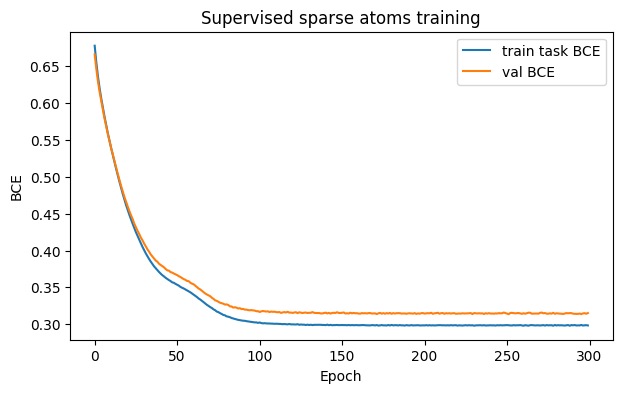

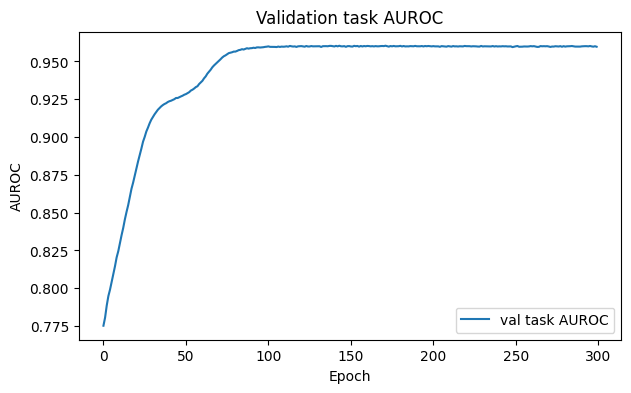

In [862]:
# ============================================================
# Block 10: Plot training curves
# ============================================================
# This helps check whether training is stable and whether validation BCE improves.

plt.figure(figsize=(7, 4))
plt.plot(history["train_task_bce"], label="train task BCE")
plt.plot(history["val_bce"], label="val BCE")
plt.xlabel("Epoch")
plt.ylabel("BCE")
plt.title("Supervised sparse atoms training")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["val_auc"], label="val task AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("Validation task AUROC")
plt.legend()
plt.show()

In [863]:
# ============================================================
# Block 11: Extract learned atom activations on train/test
# ============================================================
# After training, compute:
#
#   z = V^T r
#
# These are the learned residual atom activations.

@torch.no_grad()
def get_atom_activations(model, R, C, batch_size=2048):
    """
    Computes atom activations z for a full dataset.
    """

    model.eval()

    R_tensor = torch.tensor(R, dtype=torch.float32)
    C_tensor = torch.tensor(C, dtype=torch.float32)

    ds = TensorDataset(R_tensor, C_tensor)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_z = []

    for r, c in loader:
        r = r.to(device)
        c = c.to(device)

        _, z, _ = model(r, c)
        all_z.append(z.detach().cpu())

    return torch.cat(all_z, dim=0).numpy()


Z_train = get_atom_activations(model, R_train, C_train)
Z_test  = get_atom_activations(model, R_test, C_test)

print("Z_train:", Z_train.shape)
print("Z_test:", Z_test.shape)

Z_train: (30000, 7)
Z_test: (10000, 7)


In [864]:
# ============================================================
# Block 12: Compute AUC matrix between atoms and hidden concepts
# ============================================================
# This evaluates whether each learned atom corresponds to a ground-truth
# hidden concept.
#
# We use sign-invariant AUC:
#
#   max(AUC(z_j, h_l), 1 - AUC(z_j, h_l))
#
# because atom signs are arbitrary.

def auc_matrix_sign_invariant(binary_labels, scores):
    """
    binary_labels: shape (n, L), e.g. hidden concepts
    scores:        shape (n, M), e.g. atom activations

    Returns:
      aucs: shape (L, M)
    """

    binary_labels = np.asarray(binary_labels)
    scores = np.asarray(scores)

    L = binary_labels.shape[1]
    M = scores.shape[1]

    aucs = np.full((L, M), np.nan)

    for l in range(L):
        y = binary_labels[:, l]

        # Skip concepts that have only one class.
        if len(np.unique(y)) < 2:
            continue

        for j in range(M):
            s = scores[:, j]

            auc = roc_auc_score(y, s)

            # Sign-invariant version.
            aucs[l, j] = max(auc, 1.0 - auc)

    return aucs

In [865]:
# ============================================================
# Block 13: Load hidden concept labels and evaluate atoms
# ============================================================
# Change the key below if your hidden concept labels have a different name.
#
# Common alternatives might be:
#   "hidden_concepts"
#   "hidden_signal"
#   "hidden_residuals"
#   "c_hid"

H_test = to_numpy_safe(test_data["hidden_residuals"]).astype(np.float32)

auc_atoms_hidden = auc_matrix_sign_invariant(H_test, Z_test)

print("Atom-hidden AUC matrix:", auc_atoms_hidden.shape)
print("Best AUC per hidden concept:")
print(np.nanmax(auc_atoms_hidden, axis=1))

Atom-hidden AUC matrix: (20, 7)
Best AUC per hidden concept:
[0.52043511 0.54273862 0.90599739 0.50750446 0.64275908 0.9028504
 0.51244162 0.92436433 0.51223137 0.51384278 0.51353019 0.50937159
 0.51173122 0.50829105 0.90437581 0.50934993 0.50854271 0.91513301
 0.51196836 0.51251897]


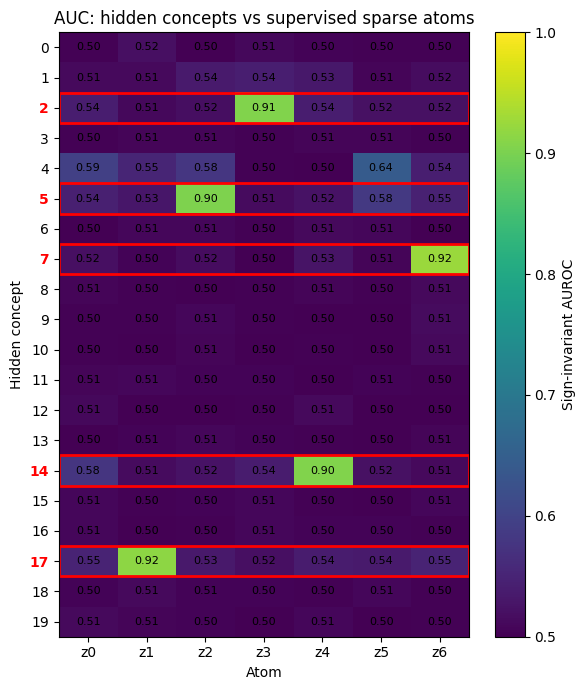

In [866]:
# ============================================================
# Block 14: Plot AUC heatmap: hidden concepts vs learned atoms
# ============================================================
# Rows are hidden concepts.
# Columns are learned atoms.
#
# Ideally, task-relevant hidden concepts should have one strong atom each.

def plot_auc_heatmap(auc_mat, title, x_label="Atom", y_label="Hidden concept", highlight_rows=None):
    plt.figure(figsize=(max(6, auc_mat.shape[1] * 0.8), max(5, auc_mat.shape[0] * 0.35)))
    plt.imshow(auc_mat, aspect="auto", vmin=0.5, vmax=1.0)
    plt.colorbar(label="Sign-invariant AUROC")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    plt.xticks(np.arange(auc_mat.shape[1]), [f"z{j}" for j in range(auc_mat.shape[1])])
    plt.yticks(np.arange(auc_mat.shape[0]), [str(i) for i in range(auc_mat.shape[0])])

    for i in range(auc_mat.shape[0]):
        for j in range(auc_mat.shape[1]):
            val = auc_mat[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
                
    if highlight_rows is not None:
        for r in highlight_rows:
            plt.gca().add_patch(plt.Rectangle((-0.5, r - 0.5), auc_mat.shape[1], 1,
                                              fill=False, edgecolor="red", lw=2))
        for tick in plt.gca().get_yticklabels():
            if int(tick.get_text()) in highlight_rows:
                tick.set_color("red")
                tick.set_fontweight("bold")

    plt.tight_layout()
    plt.show()


plot_auc_heatmap(
    auc_atoms_hidden,
    title="AUC: hidden concepts vs supervised sparse atoms",
    highlight_rows=hid_task_idx.tolist()
)

In [867]:
# ============================================================
# Block 15: Hungarian matching for task-relevant hidden concepts
# ============================================================
# If you know the task-relevant hidden concepts, use them here.


# Select only task-relevant rows from the AUC matrix.
auc_relevant = auc_atoms_hidden[hid_task_idx, :]

# Hungarian matching maximizes total AUC.
# scipy minimizes cost, so use negative AUC as cost.
row_ind, col_ind = linear_sum_assignment(-auc_relevant)

matched_hidden = hid_task_idx[row_ind]
matched_atoms = col_ind
matched_aucs = auc_relevant[row_ind, col_ind]

print("Hungarian matching: hidden concept -> atom")
for h, z_j, auc in zip(matched_hidden, matched_atoms, matched_aucs):
    print(f"h_{h:02d} -> z_{z_j:02d} | AUC = {auc:.3f}")

print(f"Mean matched AUC: {matched_aucs.mean():.3f}")

Hungarian matching: hidden concept -> atom
h_05 -> z_02 | AUC = 0.903
h_14 -> z_04 | AUC = 0.904
h_07 -> z_06 | AUC = 0.924
h_02 -> z_03 | AUC = 0.906
h_17 -> z_01 | AUC = 0.915
Mean matched AUC: 0.911


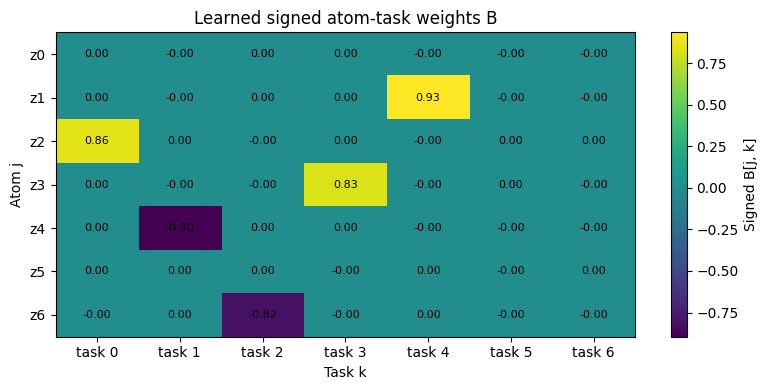

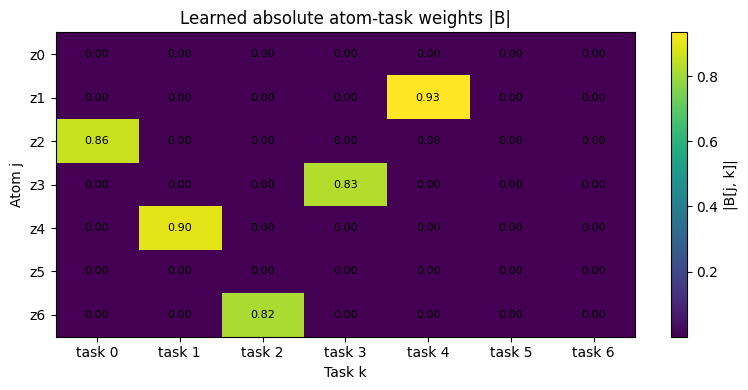

In [868]:
# ============================================================
# Block 16: Inspect learned B matrix
# ============================================================
# B[j, k] tells us how much atom j contributes to task k.
#
# If the model worked, tasks 0,...,4 should connect sparsely to atoms
# matching h_5, h_14, h_7, h_2, h_17.

B = model.B.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.imshow(B, aspect="auto")
plt.colorbar(label="Signed B[j, k]")
plt.xlabel("Task k")
plt.ylabel("Atom j")
plt.title("Learned signed atom-task weights B")
plt.xticks(np.arange(B.shape[1]), [f"task {k}" for k in range(B.shape[1])])
plt.yticks(np.arange(B.shape[0]), [f"z{j}" for j in range(B.shape[0])])

for j in range(B.shape[0]):
    for k in range(B.shape[1]):
        plt.text(k, j, f"{B[j, k]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.imshow(np.abs(B), aspect="auto")
plt.colorbar(label="|B[j, k]|")
plt.xlabel("Task k")
plt.ylabel("Atom j")
plt.title("Learned absolute atom-task weights |B|")
plt.xticks(np.arange(B.shape[1]), [f"task {k}" for k in range(B.shape[1])])
plt.yticks(np.arange(B.shape[0]), [f"z{j}" for j in range(B.shape[0])])

for j in range(B.shape[0]):
    for k in range(B.shape[1]):
        plt.text(k, j, f"{abs(B[j, k]):.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [869]:
print("Hidden concept weights (K task bits highlighted):")
display(df_w_hid)

print(f"task_map_obs: {task_map_obs}")
df_w_obs["obs_task_j"] = df_w_obs["observed_concept_idx"].map(task_map_obs)

print("\nObserved concept weights (J task bits highlighted):")
display(df_w_obs)

Hidden concept weights (K task bits highlighted):


,hidden_concept_idx,weight,abs_weight,is_task_bit,hid_task_k
5,5,0.974940,0.974940,True,0
14,14,-0.952066,0.952066,True,1
7,7,0.891934,0.891934,True,2
2,2,-0.609588,0.609588,True,3
17,17,0.549488,0.549488,True,4


task_map_obs: {4: 0, 7: 1}

Observed concept weights (J task bits highlighted):


,observed_concept_idx,weight,abs_weight,is_task_bit,obs_task_j
4,4,0.930378,0.930378,True,0.0
7,7,0.841165,0.841165,True,1.0
1,1,0.621388,0.621388,False,NaN


In [870]:
# ============================================================
# Block 17: Compare matched atoms with learned task wiring
# ============================================================
# This checks whether the atom aligned with h_l is actually used by
# the task that depends on h_l.
#


print("Matched hidden concept, matched atom, true task, |B[atom, task]|")
for h, z_j, auc in zip(matched_hidden, matched_atoms, matched_aucs):
    task_k = task_map_hid[int(h)]
    print(
        f"h_{int(h):02d} -> z_{int(z_j):02d} | "
        f"task={task_k} | "
        f"AUC={auc:.3f} | "
        f"|B|={abs(B[int(z_j), task_k]):.3f}"
    )

Matched hidden concept, matched atom, true task, |B[atom, task]|
h_05 -> z_02 | task=0 | AUC=0.903 | |B|=0.857
h_14 -> z_04 | task=1 | AUC=0.904 | |B|=0.895
h_07 -> z_06 | task=2 | AUC=0.924 | |B|=0.815
h_02 -> z_03 | task=3 | AUC=0.906 | |B|=0.828
h_17 -> z_01 | task=4 | AUC=0.915 | |B|=0.935


# Predictive power of c_mu

In [871]:
# ============================================================
# Diagnostic 2: compare c_mu-only vs c_mu + res_mu probes
# ============================================================
# This measures the conditional value of the residual channel for each task.
#
# If adding res_mu gives a large improvement on hidden tasks, then res_mu
# contains task-relevant information beyond c_mu.
#
# If improvement is small, then c_mu already explains most task labels.

# NOTE: use the raw arrays from Block 2 (C_*_raw / R_*_raw) throughout --
# don't touch the standardized C_train / R_train that the atom model
# (Blocks 3-9) depends on. The probe pipelines standardize internally.

Xc_train = C_train_raw
Xc_test  = C_test_raw

Xcr_train = np.concatenate([C_train_raw, R_train_raw], axis=1)
Xcr_test  = np.concatenate([C_test_raw, R_test_raw], axis=1)

rows = []

for k in range(num_tasks):
    y_tr = Y_train[:, k]
    y_te = Y_test[:, k]

    # -----------------------------
    # c_mu-only classifier
    # -----------------------------
    clf_c = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
    clf_c.fit(Xc_train, y_tr)

    scores_c = clf_c.decision_function(Xc_test)
    probs_c = clf_c.predict_proba(Xc_test)[:, 1]

    # -----------------------------
    # c_mu + res_mu classifier
    # -----------------------------
    clf_cr = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
    clf_cr.fit(Xcr_train, y_tr)

    scores_cr = clf_cr.decision_function(Xcr_test)
    probs_cr = clf_cr.predict_proba(Xcr_test)[:, 1]

    # -----------------------------
    # Metrics
    # -----------------------------
    if len(np.unique(y_te)) == 2:
        auc_c = roc_auc_score(y_te, scores_c)
        auc_cr = roc_auc_score(y_te, scores_cr)

        bce_c = log_loss(y_te, probs_c, labels=[0, 1])
        bce_cr = log_loss(y_te, probs_cr, labels=[0, 1])

        ap_c = average_precision_score(y_te, scores_c)
        ap_cr = average_precision_score(y_te, scores_cr)
    else:
        auc_c = auc_cr = np.nan
        bce_c = bce_cr = np.nan
        ap_c = ap_cr = np.nan

    rows.append({
        "task": k,
        "task_type": "hidden_task" if k < num_hid_tasks else "observed_task",

        "auc_c_only": auc_c,
        "auc_c_plus_r": auc_cr,
        "delta_auc": auc_cr - auc_c,

        "bce_c_only": bce_c,
        "bce_c_plus_r": bce_cr,
        "delta_bce_improvement": bce_c - bce_cr,

        "ap_c_only": ap_c,
        "ap_c_plus_r": ap_cr,
        "delta_ap": ap_cr - ap_c,
    })


conditional_df = pd.DataFrame(rows)

print("Per-task conditional residual value:")
display(conditional_df)

print("\nMean by task type:")
display(
    conditional_df
    .groupby("task_type")[[
        "auc_c_only",
        "auc_c_plus_r",
        "delta_auc",
        "bce_c_only",
        "bce_c_plus_r",
        "delta_bce_improvement",
        "ap_c_only",
        "ap_c_plus_r",
        "delta_ap",
    ]]
    .mean()
)

Per-task conditional residual value:


,task,task_type,auc_c_only,auc_c_plus_r,delta_auc,bce_c_only,bce_c_plus_r,delta_bce_improvement,ap_c_only,ap_c_plus_r,delta_ap
0,0,hidden_task,0.715937,0.981825,0.265888,0.620926,0.176201,0.444724,0.698366,0.983838,0.285472
1,1,hidden_task,0.615295,0.977682,0.362387,0.672114,0.194846,0.477267,0.614552,0.980298,0.365746
2,2,hidden_task,0.749408,0.983647,0.234239,0.594523,0.168437,0.426086,0.724291,0.985768,0.261476
3,3,hidden_task,0.715633,0.979065,0.263433,0.619685,0.187085,0.432599,0.694072,0.981410,0.287339
4,4,hidden_task,0.615245,0.983432,0.368187,0.672726,0.169408,0.503318,0.620365,0.984936,0.364571
5,5,observed_task,0.935456,0.989052,0.053597,0.302822,0.141915,0.160906,0.950862,0.990145,0.039283
6,6,observed_task,0.946619,0.989757,0.043139,0.273804,0.138401,0.135403,0.960259,0.990634,0.030375



Mean by task type:


,auc_c_only,auc_c_plus_r,delta_auc,bce_c_only,bce_c_plus_r,delta_bce_improvement,ap_c_only,ap_c_plus_r,delta_ap
task_type,,,,,,,,,
hidden_task,0.682303,0.981130,0.298827,0.635995,0.179196,0.456799,0.670329,0.983250,0.312921
observed_task,0.941037,0.989405,0.048368,0.288313,0.140158,0.148155,0.955560,0.990389,0.034829


# Get shared_obs_score and shared_hid_score

In [872]:
def median_split(s):
    """Binary split at the median, breaking ties by rank instead of raw value.
    Avoids degenerate single-class labels when s has a tied point-mass
    (e.g. zero-inflated per-concept signals at low/zero beta)."""
    ranks = rankdata(s, method="ordinal")
    return (ranks > len(s) / 2).astype(np.float32)


def standardize_full(z):
    return (z - z.mean()) / (z.std() + 1e-8)

In [873]:
print(hid_task_idx)
train_w_hid = to_numpy_safe(train_data["w_hid"]).astype(float)
print(train_w_hid)

tensor([ 5, 14,  7,  2, 17])
[ 0.          0.         -0.60958761  0.          0.          0.97494006
  0.          0.89193428  0.          0.          0.          0.
  0.          0.         -0.95206612  0.          0.          0.54948807
  0.          0.        ]


In [874]:
train_s_hid = to_numpy_safe(train_data["s_hid"]).astype(float)
train_s_obs = to_numpy_safe(train_data["s_obs"]).astype(float)

train_w_hid = to_numpy_safe(train_data["w_hid"]).astype(float)
train_w_obs = to_numpy_safe(train_data["w_obs"]).astype(float)

train_concept_signal = to_numpy_safe(train_data["concept_signal"]).astype(float)
train_residual_signal = to_numpy_safe(train_data["hidden_residual_signal"]).astype(float)
val_concept_signal = to_numpy_safe(val_data["concept_signal"]).astype(float)
val_residual_signal = to_numpy_safe(val_data["hidden_residual_signal"]).astype(float)
test_concept_signal = to_numpy_safe(test_data["concept_signal"]).astype(float)
test_residual_signal = to_numpy_safe(test_data["hidden_residual_signal"]).astype(float)

# concatenate all splits to recover full-population statistics
full_concept_signal  = np.concatenate([train_concept_signal,  val_concept_signal,  test_concept_signal])
full_residual_signal = np.concatenate([train_residual_signal, val_residual_signal, test_residual_signal])
n_full = full_concept_signal.shape[0]



shared_obs_score = standardize_full(full_concept_signal @ train_w_obs)
shared_hid_score = standardize_full(full_residual_signal @ train_w_hid)

pattern = re.compile(
    r"_alpha_(?P<alpha>-?\d+(?:\.\d+)?)"
    r"_beta_(?P<beta>-?\d+(?:\.\d+)?)"
)

match = pattern.search(EXPERIMENT_PATH)

if match:
    alpha = float(match["alpha"])
    beta = float(match["beta"])
else:
    raise ValueError(f"Could not parse alpha/beta from EXPERIMENT_PATH: {EXPERIMENT_PATH}")

# num_hid_tasks / num_obs_tasks come from the config parse in the
# "Specify experiment" cell -- do not hardcode them here.
assert num_hid_tasks == len(hid_task_idx) and num_obs_tasks == len(obs_task_idx)


manual_s_hid = np.zeros((n_full, num_hid_tasks))
manual_s_obs = np.zeros((n_full, num_obs_tasks))

for k in range(num_hid_tasks):
    idx = hid_task_idx[k]
    hid_specific = standardize_full(full_residual_signal[:, idx] * np.abs(train_w_hid[idx]))
    manual_s_hid[:, k] = alpha * hid_specific + beta * shared_obs_score


    
for k in range(num_obs_tasks):
    idx = obs_task_idx[k]
    obs_specific = standardize_full(full_concept_signal[:, idx] * np.abs(train_w_obs[idx]))
    manual_s_obs[:, k] = alpha * obs_specific + beta * shared_hid_score




gt_train_s_hid = to_numpy_safe(train_data["s_hid"]).astype(float)
gt_train_s_obs = to_numpy_safe(train_data["s_obs"]).astype(float)
gt_val_s_hid = to_numpy_safe(val_data["s_hid"]).astype(float)
gt_val_s_obs = to_numpy_safe(val_data["s_obs"]).astype(float)
gt_test_s_hid = to_numpy_safe(test_data["s_hid"]).astype(float)
gt_test_s_obs = to_numpy_safe(test_data["s_obs"]).astype(float)

gt_s_hid = np.concatenate([gt_train_s_hid, gt_val_s_hid, gt_test_s_hid])
gt_s_obs = np.concatenate([gt_train_s_obs, gt_val_s_obs, gt_test_s_obs])


# check if all entries in two tensors are the same
print(np.allclose(manual_s_hid, gt_s_hid, atol=1e-5))
print(np.allclose(manual_s_obs, gt_s_obs, atol=1e-5))



True
True


# Which atom matches shared observed score

In [875]:
print(Z_test.shape)
n_train = len(train_concept_signal)
n_val = len(val_concept_signal)
n_test = len(test_concept_signal)

test_start = n_train + n_val
test_end = test_start + n_test



test_shared_obs_score = np.asarray(
    shared_obs_score[test_start:test_end]
).reshape(-1, 1)


(10000, 7)


In [876]:
# ============================================================
# Correlation: atom z6 vs the true shared-background term (shared_obs_score)
# ============================================================
from scipy.stats import pearsonr
from sklearn.metrics import roc_auc_score

atom6_test = Z_test[:, 6]
shared_obs_test = test_shared_obs_score.ravel()


# Sign-invariant AUC, consistent with how atoms were scored elsewhere in this notebook
# (atom sign is arbitrary since V's columns are only fixed up to normalization).
y_bg = (shared_obs_test > np.median(shared_obs_test)).astype(int)
auc = roc_auc_score(y_bg, atom6_test)
print(f"Sign-invariant AUC(z6, shared_obs_score) = {max(auc, 1 - auc):.4f}")

# For comparison, do the same for the two "idle" atoms (z1, z2, z5) so you can see
# whether z6 stands out as uniquely aligned with the background term.
for j in [0, 1, 2, 3, 4, 5, 6]:
    r_j, _ = pearsonr(Z_test[:, j], shared_obs_test)
    auc_j = roc_auc_score(y_bg, Z_test[:, j])
    print(f"  z{j}: r={r_j:+.3f}  AUC={max(auc_j, 1-auc_j):.3f}")


Sign-invariant AUC(z6, shared_obs_score) = 0.7186
  z0: r=+0.374  AUC=0.733
  z1: r=+0.316  AUC=0.622
  z2: r=+0.314  AUC=0.620
  z3: r=+0.162  AUC=0.553
  z4: r=-0.169  AUC=0.532
  z5: r=-0.124  AUC=0.563
  z6: r=-0.498  AUC=0.719


# Power of knowing shared_obs_score on y_hid

In [877]:
# Logistic regression:
#   shared_obs_score alone
#   shared_hid_score alone
#   shared_obs_score + shared_hid_score
# for predicting hidden-task labels y_hid

import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# Split shared scores into train and test
# ------------------------------------------------------------

n_train = len(train_concept_signal)
n_val = len(val_concept_signal)
n_test = len(test_concept_signal)

test_start = n_train + n_val
test_end = test_start + n_test

train_shared_obs_score = np.asarray(
    shared_obs_score[:n_train]
).reshape(-1, 1)

test_shared_obs_score = np.asarray(
    shared_obs_score[test_start:test_end]
).reshape(-1, 1)

train_shared_hid_score = np.asarray(
    shared_hid_score[:n_train]
).reshape(-1, 1)

test_shared_hid_score = np.asarray(
    shared_hid_score[test_start:test_end]
).reshape(-1, 1)


# Predictor matrices
X_obs_train = train_shared_obs_score
X_obs_test = test_shared_obs_score

X_hid_train = train_shared_hid_score
X_hid_test = test_shared_hid_score

X_both_train = np.column_stack([
    train_shared_obs_score.ravel(),
    train_shared_hid_score.ravel(),
])

X_both_test = np.column_stack([
    test_shared_obs_score.ravel(),
    test_shared_hid_score.ravel(),
])


# Only hidden-task labels
Y_hid_train = np.asarray(Y_train)[:, :num_hid_tasks]
Y_hid_test = np.asarray(Y_test)[:, :num_hid_tasks]


def fit_auc(X_train, X_test, y_train, y_test):
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return np.nan

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000),
    )
    clf.fit(X_train, y_train)

    scores = clf.decision_function(X_test)

    return roc_auc_score(y_test, scores)


rows = []

for k in range(num_hid_tasks):
    y_tr = Y_hid_train[:, k]
    y_te = Y_hid_test[:, k]

    auc_obs = fit_auc(
        X_obs_train,
        X_obs_test,
        y_tr,
        y_te,
    )

    auc_hid = fit_auc(
        X_hid_train,
        X_hid_test,
        y_tr,
        y_te,
    )

    auc_both = fit_auc(
        X_both_train,
        X_both_test,
        y_tr,
        y_te,
    )

    rows.append({
        "task": k,
        "auc_shared_obs": auc_obs,
        "auc_shared_hid": auc_hid,
        "auc_shared_obs_plus_hid": auc_both,
        "delta_auc_add_hid": auc_both - auc_obs,
        "delta_auc_add_obs": auc_both - auc_hid,
    })


shared_score_auc_df = pd.DataFrame(rows)

print("Per-hidden-task AUROC:")
display(shared_score_auc_df)

print("\nMean AUROC across hidden tasks:")
display(
    shared_score_auc_df
    .drop(columns="task")
    .mean()
    .to_frame("mean")
    .T
)

Per-hidden-task AUROC:


,task,auc_shared_obs,auc_shared_hid,auc_shared_obs_plus_hid,delta_auc_add_hid,delta_auc_add_obs
0,0,0.647417,0.730481,0.775904,0.128487,0.045423
1,1,0.658139,0.681162,0.776325,0.118186,0.095163
2,2,0.744833,0.687549,0.803210,0.058377,0.115661
3,3,0.644025,0.612986,0.705533,0.061508,0.092547
4,4,0.650497,0.637621,0.700953,0.050456,0.063331



Mean AUROC across hidden tasks:


,auc_shared_obs,auc_shared_hid,auc_shared_obs_plus_hid,delta_auc_add_hid,delta_auc_add_obs
mean,0.668982,0.66996,0.752385,0.083403,0.082425


# How predictive c_mu is of shared_obs and shared_hid

In [878]:
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error


C_train = np.asarray(train_data["c_mu"])
C_test = np.asarray(test_data["c_mu"])

y_obs_train = np.asarray(train_shared_obs_score).ravel()
y_obs_test = np.asarray(test_shared_obs_score).ravel()

y_hid_train = np.asarray(train_shared_hid_score).ravel()
y_hid_test = np.asarray(test_shared_hid_score).ravel()


def fit_score_probe(C_train, C_test, y_train, y_test, target_name):
    reg = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-4, 4, 25)),
    )

    reg.fit(C_train, y_train)
    y_pred = reg.predict(C_test)

    return {
        "target": target_name,
        "test_r2": r2_score(y_test, y_pred),
        "test_rmse": mean_squared_error(
            y_test,
            y_pred,
        ) ** 0.5,
        "ridge_alpha": reg.named_steps["ridgecv"].alpha_,
    }


rows = [
    fit_score_probe(
        C_train,
        C_test,
        y_obs_train,
        y_obs_test,
        "shared_obs_score",
    ),
    fit_score_probe(
        C_train,
        C_test,
        y_hid_train,
        y_hid_test,
        "shared_hid_score",
    ),
]

cmu_score_probe_df = pd.DataFrame(rows)
display(cmu_score_probe_df)

,target,test_r2,test_rmse,ridge_alpha
0,shared_obs_score,0.559221,0.656870,10.0
1,shared_hid_score,0.085492,0.968941,100.0


## Sigma of different datasets

In [879]:
import torch
root_data_dir = "datasets/multilabel_synthetic/"
dataset = "testing_local_hid_tasks_5_obs_tasks_2_alpha_1.0_beta_1.0_rho_cr0.5_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.5_hid_dim_20_obs_dim_10_w_ratio_0.4_standardize_True_grouped3_seed_0"

sigma_path = os.path.join(root_data_dir, dataset, "test", "Sigma.pt")
sigma = torch.load(sigma_path)

# heatmap of sigma
plt.figure(figsize=(30, 20))
sns.heatmap(sigma, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Data covariance")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'datasets/multilabel_synthetic/testing_local_hid_tasks_5_obs_tasks_2_alpha_1.0_beta_1.0_rho_cr0.5_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.5_hid_dim_20_obs_dim_10_w_ratio_0.4_standardize_True_grouped3_seed_0/test/Sigma.pt'